# PSY 39200 Introduction to Computational Psychology and AI

## Week 03 Probability and Statistics

## There are 4 sets of questions and 5 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University

### Part of this tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed): https://neuromatch.io/open-education-resources/

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import norm  # the normal probability distribution

In [ ]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
import ipywidgets as widgets  # interactive display
from ipywidgets import interact, fixed, HBox, Layout, VBox, interactive, Label, interact_manual
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

In [ ]:
# @title Plotting Functions

def plot_random_sample(x, y, figtitle = None):
  """ Plot the random sample between 0 and 1 for both the x and y axes.

    Args:
      x (ndarray): array of x coordinate values across the random sample
      y (ndarray): array of y coordinate values across the random sample
      figtitle (str): title of histogram plot (default is no title)

    Returns:
      Nothing.
  """
  fig, ax = plt.subplots()
  ax.set_xlabel('x')
  ax.set_ylabel('y')
  plt.xlim([-0.25, 1.25]) # set x and y axis range to be a bit less than 0 and greater than 1
  plt.ylim([-0.25, 1.25])
  plt.scatter(dataX, dataY)
  if figtitle is not None:
    fig.suptitle(figtitle, size=16)
  plt.show()


def plot_random_walk(x, y, figtitle = None):
  """ Plots the random walk within the range 0 to 1 for both the x and y axes.

    Args:
      x (ndarray): array of steps in x direction
      y (ndarray): array of steps in y direction
      figtitle (str): title of histogram plot (default is no title)

    Returns:
      Nothing.
  """
  fig, ax = plt.subplots()
  plt.plot(x,y,'b-o', alpha = 0.5)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)
  ax.set_xlabel('x location')
  ax.set_ylabel('y location')
  plt.plot(x[0], y[0], 'go')
  plt.plot(x[-1], y[-1], 'ro')

  if figtitle is not None:
    fig.suptitle(figtitle, size=16)
  plt.show()


def plot_hist(data, xlabel, figtitle = None, num_bins = None):
  """ Plot the given data as a histogram.

    Args:
      data (ndarray): array with data to plot as histogram
      xlabel (str): label of x-axis
      figtitle (str): title of histogram plot (default is no title)
      num_bins (int): number of bins for histogram (default is 10)

    Returns:
      count (ndarray): number of samples in each histogram bin
      bins (ndarray): center of each histogram bin
  """
  fig, ax = plt.subplots()
  ax.set_xlabel(xlabel)
  ax.set_ylabel('Count')
  if num_bins is not None:
    count, bins, _ = plt.hist(data, bins = num_bins)
  else:
    count, bins, _ = plt.hist(data, bins = np.arange(np.min(data)-.5, np.max(data)+.6)) # 10 bins default
  if figtitle is not None:
    fig.suptitle(figtitle, size=16)
  plt.show()
  return count, bins


def my_plot_single(x, px):
  """
  Plots normalized Gaussian distribution

    Args:
        x (numpy array of floats):     points at which the likelihood has been evaluated
        px (numpy array of floats):    normalized probabilities for prior evaluated at each `x`

    Returns:
        Nothing.
  """
  if px is None:
      px = np.zeros_like(x)

  fig, ax = plt.subplots()
  ax.plot(x, px, '-', color='C2', linewidth=2, label='Prior')
  ax.legend()
  ax.set_ylabel('Probability')
  ax.set_xlabel('Orientation (Degrees)')
  plt.show()


def plot_gaussian_samples_true(samples, xspace, mu, sigma, xlabel, ylabel):
  """ Plot a histogram of the data samples on the same plot as the gaussian
  distribution specified by the give mu and sigma values.

    Args:
      samples (ndarray): data samples for gaussian distribution
      xspace (ndarray): x values to sample from normal distribution
      mu (scalar): mean parameter of normal distribution
      sigma (scalar): variance parameter of normal distribution
      xlabel (str): the label of the x-axis of the histogram
      ylabel (str): the label of the y-axis of the histogram

    Returns:
      Nothing.
  """
  fig, ax = plt.subplots()
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  # num_samples = samples.shape[0]

  count, bins, _ = plt.hist(samples, density=True)
  plt.plot(xspace, norm.pdf(xspace, mu, sigma),'r-')
  plt.show()

In [ ]:
# @title Plotting functions

def plot_hist(data, xlabel, figtitle = None, num_bins = None):
  """ Plot the given data as a histogram.

    Args:
      data (ndarray): array with data to plot as histogram
      xlabel (str): label of x-axis
      figtitle (str): title of histogram plot (default is no title)
      num_bins (int): number of bins for histogram (default is 10)

    Returns:
      count (ndarray): number of samples in each histogram bin
      bins (ndarray): center of each histogram bin
  """
  fig, ax = plt.subplots()
  ax.set_xlabel(xlabel)
  ax.set_ylabel('Count')
  if num_bins is not None:
    count, bins, _ = plt.hist(data, max(data), bins=num_bins)
  else:
    count, bins, _ = plt.hist(data, max(data))  # 10 bins default
  if figtitle is not None:
    fig.suptitle(figtitle, size=16)
  plt.show()
  return count, bins


def plot_gaussian_samples_true(samples, xspace, mu, sigma, xlabel, ylabel):
  """ Plot a histogram of the data samples on the same plot as the gaussian
  distribution specified by the give mu and sigma values.

    Args:
      samples (ndarray): data samples for gaussian distribution
      xspace (ndarray): x values to sample from normal distribution
      mu (scalar): mean parameter of normal distribution
      sigma (scalar): variance parameter of normal distribution
      xlabel (str): the label of the x-axis of the histogram
      ylabel (str): the label of the y-axis of the histogram

    Returns:
      Nothing.
  """
  fig, ax = plt.subplots()
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  # num_samples = samples.shape[0]

  count, bins, _ = plt.hist(samples, density=True)  # probability density function

  plt.plot(xspace, norm.pdf(xspace, mu, sigma), 'r-')
  plt.show()


def plot_likelihoods(likelihoods, mean_vals, variance_vals):
  """ Plot the likelihood values on a heatmap plot where the x and y axes match
  the mean and variance parameter values the likelihoods were computed for.

    Args:
      likelihoods (ndarray): array of computed likelihood values
      mean_vals (ndarray): array of mean parameter values for which the
                            likelihood was computed
      variance_vals (ndarray): array of variance parameter values for which the
                            likelihood was computed

    Returns:
      Nothing.
  """
  fig, ax = plt.subplots()
  im = ax.imshow(likelihoods)

  cbar = ax.figure.colorbar(im, ax=ax)
  cbar.ax.set_ylabel('log likelihood', rotation=-90, va="bottom")

  ax.set_xticks(np.arange(len(mean_vals)))
  ax.set_yticks(np.arange(len(variance_vals)))
  ax.set_xticklabels(mean_vals)
  ax.set_yticklabels(variance_vals)
  ax.set_xlabel('Mean')
  ax.set_ylabel('Variance')
  plt.show()


def posterior_plot(x, likelihood=None, prior=None,
                   posterior_pointwise=None, ax=None):
  """
  Plots normalized Gaussian distributions and posterior.

    Args:
        x (numpy array of floats):         points at which the likelihood has been evaluated
        auditory (numpy array of floats):  normalized probabilities for auditory likelihood evaluated at each `x`
        visual (numpy array of floats):    normalized probabilities for visual likelihood evaluated at each `x`
        posterior (numpy array of floats): normalized probabilities for the posterior evaluated at each `x`
        ax: Axis in which to plot. If None, create new axis.

    Returns:
        Nothing.
  """
  if likelihood is None:
      likelihood = np.zeros_like(x)

  if prior is None:
      prior = np.zeros_like(x)

  if posterior_pointwise is None:
      posterior_pointwise = np.zeros_like(x)

  if ax is None:
    fig, ax = plt.subplots()

  ax.plot(x, likelihood, '-C1', linewidth=2, label='Auditory')
  ax.plot(x, prior, '-C0', linewidth=2, label='Visual')
  ax.plot(x, posterior_pointwise, '-C2', linewidth=2, label='Posterior')
  ax.legend()
  ax.set_ylabel('Probability')
  ax.set_xlabel('Orientation (Degrees)')
  plt.show()

  return ax


def plot_classical_vs_bayesian_normal(num_points, mu_classic, var_classic,
                                      mu_bayes, var_bayes):
  """ Helper function to plot optimal normal distribution parameters for varying
  observed sample sizes using both classic and Bayesian inference methods.

    Args:
      num_points (int): max observed sample size to perform inference with
      mu_classic (ndarray): estimated mean parameter for each observed sample size
                                using classic inference method
      var_classic (ndarray): estimated variance parameter for each observed sample size
                                using classic inference method
      mu_bayes (ndarray): estimated mean parameter for each observed sample size
                                using Bayesian inference method
      var_bayes (ndarray): estimated variance parameter for each observed sample size
                                using Bayesian inference method

    Returns:
      Nothing.
  """
  xspace = np.linspace(0, num_points, num_points)
  fig, ax = plt.subplots()
  ax.set_xlabel('n data points')
  ax.set_ylabel('mu')
  plt.plot(xspace, mu_classic,'r-', label="Classical")
  plt.plot(xspace, mu_bayes,'b-', label="Bayes")
  plt.legend()
  plt.show()

  fig, ax = plt.subplots()
  ax.set_xlabel('n data points')
  ax.set_ylabel('sigma^2')
  plt.plot(xspace, var_classic,'r-', label="Classical")
  plt.plot(xspace, var_bayes,'b-', label="Bayes")
  plt.legend()
  plt.show()

# Foundations of Probability

## Sample Space and Events

- The **sample space** (denoted $S$) is the set of all possible outcomes of a random experiment.  
  Example: rolling a die: $S = \{1,2,3,4,5,6\}$.  

- An **event** is a subset of the sample space.  
  Example: The events of getting an even number when rolling a die: $E = \{2,4,6\}$.   

### Some Notations

- **$P(A \cap B)$ or $P(A, B)$:**  
  - Read as **“Probability of A and B”** (both events happen simultaneously).  
  - Alternative: **“Probability of A intersection B.”**

- **$P(A \cup B)$ or $P(A \text{ or } B)$:**  
  - Read as **“Probability of A or B”** (at least one event happens (A, B, or both)).  
  - Alternative: **“Probability of A union B.”**

### Inclusion-Exclusion Principle

- When calculating the probability of the union of two events $P(A \cup B)$, we must avoid double-counting the overlap between the two events.  

  The formula is:

  $$
  P(A \cup B) = P(A) + P(B) - P(A \cap B).
  $$

- **Why subtract $P(A \cap B)$?**  
  - Adding $P(A) + P(B)$ counts the outcomes in both events.  
  - The overlap $P(A \cap B)$ gets counted twice, so we subtract it once.

#### Example (Die Roll):
- Sample space: $S = \{1,2,3,4,5,6\}$.  
- Let $A = \{\text{even}\} = \{2,4,6\}$, so $P(A) = 3/6$.  
- Let $B = \{\text{prime}\} = \{2,3,5\}$, so $P(B) = 3/6$.  
- Intersection: $A \cap B = \{2\}$, so $P(A \cap B) = 1/6$.  

Now apply the formula:

$$
P(A \cup B) = \tfrac{3}{6} + \tfrac{3}{6} - \tfrac{1}{6} = \tfrac{5}{6}
$$

So the probability of rolling either an even number or a prime number is $\frac{5}{6}$


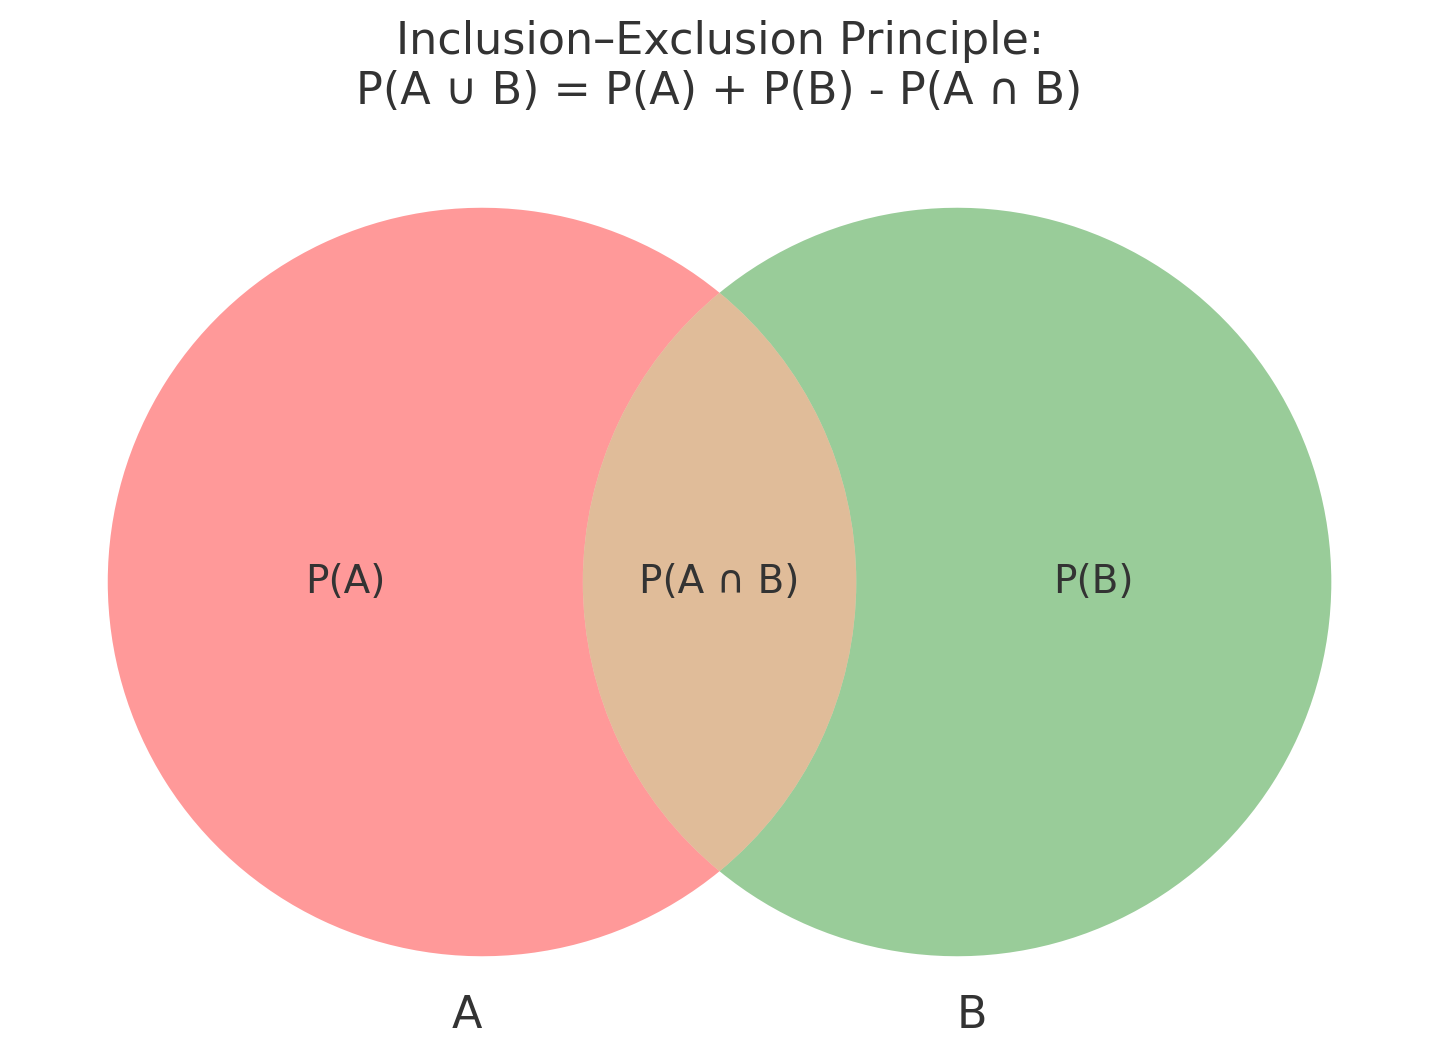

### Mutually Exclusive Events

- **Definition:**  
  Two events are **mutually exclusive** (or **disjoint**) if they cannot occur at the same time.  

  Formally:  

  $$
  A \cap B = \emptyset \quad \Rightarrow \quad P(A \cap B) = 0
  $$

- **Example (Coin Toss):**  
  Let $A = \{\text{Heads}\}$ and $B = \{\text{Tails}\}$.  
  Since a single toss cannot be both heads and tails,  

  $$
  P(A \cap B) = 0.
  $$


## Axioms of Probability  

Probability is defined using **Kolmogorov's axioms**:

1. **Non-negativity:** For any event $A$, $P(A) \geq 0$.  
2. **Normalization:** $P(S) = 1$.

   (the probability that some outcome in the sample space occurs is 1)

3. **Additivity:** If $A$ and $B$ are mutually exclusive (disjoint), then

   $$
   P(A \cup B) = P(A) + P(B).
   $$

## Conditional Probability and Independence  

- **Conditional probability:** Probability of event $A$ given event $B$ is:

  $$
  P(A \mid B) = \frac{P(A \cap B)}{P(B)}, \quad P(B) > 0.
  $$  

  Therefore,

  $$
  P(A \mid B)P(B) = P(A \cap B), \quad P(B) > 0.
  $$

- **Independence:** Events $A$ and $B$ are independent if  

  $$
  P(A \cap B) = P(A)P(B).
  $$

  If Events $A$ and $B$ are independent, then

  $$
  P(A \mid B) = \frac{P(A \cap B)}{P(B)} = \frac{P(A)P(B)}{P(B)} = P(A)
  $$

  $$
  P(B \mid A) = \frac{P(A \cap B)}{P(A)} = \frac{P(A)P(B)}{P(A)} = P(B)
  $$


# Discussion Part 1

## Law of Total Probability and Bayes' Theorem

- A **partition of the sample space** is a collection of events  

  $$
  \{B_1, B_2, \dots, B_n\}
  $$   

  such that:
  1. **Mutually exclusive:** The events do not overlap.  

     $$
     B_i \cap B_j = \emptyset \quad \text{for } i \neq j
     $$

  2. **Collectively exhaustive:** Together they cover the entire sample space.  

     $$
     B_1 \cup B_2 \cup \cdots \cup B_n = S
     $$

- **Example (Die Roll):**  
  Let the sample space be $S = \{1,2,3,4,5,6\}$.  
  One possible partition is:  

  $$
  B_1 = \{1,2\}, \quad B_2 = \{3,4\}, \quad B_3 = \{5,6\}.
  $$

  These sets do not overlap, and together they cover all six outcomes.

---

- **Law of total probability:** If $\{B_1, B_2, \dots, B_n\}$ is a **partition of the sample space**, then  

  $$
  P(A) = \sum_{i=1}^n P(A \mid B_i) P(B_i)
  $$  

  This expresses the probability of $A$ by breaking it down across all disjoint cases $B_i$. It computes $P(A)$ when $A$ can happen under several disjoint scenarios.


---

- **Bayes' theorem:** Bayes' Theorem allows us to “flip” conditional probabilities::  

  $$
  P(B_i \mid A) = \frac{P(A \cap B_i)}{P(A)} = \frac{P(A \mid B_i) P(B_i)}{P(A)} = \frac{P(A \mid B_i) P(B_i)}{\sum_{j=1}^n P(A \mid B_j) P(B_j)}
  $$  

  - $P(B_i \mid A)$ is called **posterior probability**.
  - $P(B_i)$ is called **prior probability**.
  - $P(A \mid B_i)$ is called **likelihood**.  
  - $P(A)$ is called **evidence (or marginal likelihood)**. It is calculated using the law of total probability.

  Bayes' Theorem rewrites conditional probabilities in a way that updates **beliefs** when new evidence appears.

---

- **Bayes' Theorem is about updating beliefs**:

**Example: Disease Diagnosis**

Think of Bayes' Theorem in the context of medical testing:

- **Prior:** The prevalence of the disease in the population (before any test results).  
- **Likelihood:** How consistent the test result is with having the disease  
  (e.g., test sensitivity and specificity).  
- **Posterior:** Your updated belief about whether the patient has the disease,  
  after considering both the prior prevalence and the test outcome.  
- **Evidence:** The overall probability of getting this test result,  
  accounting for both diseased and non-diseased groups (normalization).

**Mathematical Description:**  

1. Start with a **prior belief** about each hypothesis $P(B_i)$.  
   - Example: The disease is rare (say 1% prevalence).  

2. See some **evidence** $A$ (a positive test result).  

3. Ask: If hypothesis $B_i$ (getting a disease) were true, how likely is it to see this evidence $A$ (a positive test result)?  

   - This is the **likelihood** $P(A \mid B_i)$.  

4. Combine prior and likelihood (multiply them together $P(A \mid B_i)P(B_i)$) to get the **unnormalized posterior**:  

   - Hypotheses that both had high prior probability **and** make the evidence likely will get higher weight (higher posterior probability).

   - This is the **unnormalized posterior** $P(A \mid B_i)P(B_i) = P(A, B_i) = P(B_i \mid A)P(A)$.   

5. Normalize the posterior by dividing by $P(A)$ to get the **posterior probability**:  

   - Ensures that the new probabilities add up to 1 across all possible hypotheses.  

   - This is the **posterior probability** $P(B_i \mid A)$.  







### Example: Disease Diagnosis (Bayes' Theorem)

Suppose there is a medical test for a rare disease.  

- **Prior (Prevalence):** 1% of the population has the disease.  
- **Likelihood (Sensitivity or True Positive Rate):** If a patient **has the disease**, the test is **99% positive**.  
- **False Positive Rate:** If a patient **does not have the disease**, the test still has a **5% positive rate**.  
- **Posterior:** Given a positive test result, what is the probability that the patient actually has the disease?  

---

### Step 1: Probabilities
- $ \text{Prior} = P(\text{Disease}) = 0.01 $
- $ 1 - \text{Prior} = P(\text{No Disease}) = 0.99 $  
- $ \text{Likelihood} = P(\text{Positive} \mid \text{Disease}) = 0.99 $  
- $ \text{False Positive Rate} = P(\text{Positive} \mid \text{No Disease}) = 0.05 $  

---

### Step 2: Bayes' Theorem

$$
P(\text{Disease} \mid \text{Positive}) = \frac{P(A_{Positive} \mid B_{Disease}) P(B_{Disease})}{\sum_{j=
\text{{Disease, No Disease}}} P(A_{Positive} \mid B_j) P(B_j)} =
\frac{P(\text{Positive} \mid \text{Disease}) \cdot P(\text{Disease})}
     {P(\text{Positive} \mid \text{Disease}) \cdot P(\text{Disease})
     + P(\text{Positive} \mid \text{No Disease}) \cdot P(\text{No Disease})}
$$

---

### Step 3: Calculation

$$
P(\text{Disease} \mid \text{Positive}) =
\frac{0.99 \times 0.01}{0.99 \times 0.01 + 0.05 \times 0.99}
= \frac{0.0099}{0.0099 + 0.0495}
= \frac{0.0099}{0.0594}
\approx 0.167
$$

---

**Please Note:** Even with a **highly accurate test** (99% true positive rate and 5% false positive rate), if the disease is **rare (1% prevalence)**, the probability that a person with a positive test actually has the disease is only about **16.7%**.


## Question 1 and Coding Exercise 1

## Spam Email Detection (Bayes' Theorem)

**Please complete the mathematical equations below first and then compute the final result using Python**

An email filter is designed to detect spam messages.

- **Prior (Prevalence):** 20% of all incoming emails are spam.  
- **Likelihood (Sensitivity or True Positive Rate):** If an email is spam, the filter correctly marks it as spam 95% of the time.  
- **False Positive Rate:** If an email is not spam, the filter incorrectly marks it as spam 10% of the time.  

- **Posterior:** Given that an email is marked as spam, what is the probability that it is actually spam?

---

### Step 1: Probabilities
- Prior = $ P(\text{Spam}) = 0.2 $  
- $ 1 - \text{Prior} = P(\text{Not Spam}) = 0.8 $  
- Likelihood = $ P(\text{Marked Spam} \mid \text{Spam}) = 0.95 $  
- False Positive Rate = $ P(\text{Marked Spam} \mid \text{Not Spam}) = 0.1 $  

---

### Step 2: Bayes' Theorem

$$
P(\text{Spam} \mid \text{Marked Spam}) =
\frac{P(\text{Marked Spam} \mid \text{Spam}) \cdot P(\text{Spam})}
{P(\text{Marked Spam} \mid \text{Spam}) \cdot P(\text{Marked Spam}) + P(\text{Marked Spam} \mid \text{Not Spam}) \cdot P(\text{Not Spam})}
$$

---

### Step 3: Calculation

$$
P(\text{Spam} \mid \text{Marked Spam}) =
\frac{0.95 \times 0.2}{0.95 \times 0.2 + 0.1 \times 0.8}
= \frac{0.19}{0.19 + 0.08}
= \frac{0.19}{0.27}
\approx 0.7
$$

---

### Final Answer
Given that an email is flagged as spam, the probability that it is actually spam is about 70%.

In [ ]:

# You may write any Python code below to compute the result

## Given
p_spam = 0.2
p_not_spam = 1 - p_spam
p_marked_spam_given_spam = 0.95
p_marked_spam_given_not_spam = 0.1

p_spam_given_marked_spam = (p_marked_spam_given_spam * p_spam) / (p_marked_spam_given_spam * p_spam + p_marked_spam_given_not_spam * p_not_spam)
p_spam_given_marked_spam

0.7037037037037037

## Different Interpretations of Probability

Probability can be understood in different ways. Introductory courses usually start with the **frequentist interpretation**, but it is important to know there are multiple perspectives:

---

### 1. Frequentist Interpretation
- Probability is the **long-run relative frequency** of an event occurring in repeated trials.  
- Example: If you flip a fair coin many times, the proportion of heads tends to 0.5.  
- Mathematically:

  $$
  P(A) = \lim_{n \to \infty} \frac{\text{number of times A occurs in n trials}}{n}.
  $$

---

### 2. Bayesian (Subjective) Interpretation
- Probability is a **degree of belief** or confidence in a statement, given current knowledge.  
- Example: Saying "There is a 70% chance of rain tomorrow" means you assign a belief strength of 0.7 to rain, not that it will rain on 70% of tomorrows.  
- **Bayes' theorem** updates these beliefs when new evidence is observed.

---

### 3. Axiomatic (Kolmogorov) Definition
- Modern probability is defined abstractly as a **measure** (a measure is a function that assigns non-negative numbers to sets) on a sample space $S$ that satisfies three axioms:
  1. **Non-negativity:** $P(A) \geq 0$ for any event $A$.  
  2. **Normalization:** $P(S) = 1$
  
     (the probability that some outcome in the sample space occurs is 1)   
  3. **Additivity:** If $A$ and $B$ are disjoint, then

     $$
     P(A \cup B) = P(A) + P(B)
     $$

- This framework is neutral and works for both frequentist and Bayesian applications.

---

In practice:
- **Frequentist** is common in sciences with repeatable experiments.  
- **Bayesian** is common in psychology (e.g. decision making), Artificial Intelligence, and situations with uncertainty and prior knowledge.  
- **Axiomatic** is the mathematical foundation that supports both.


# Random Variables

A **random variable** is a number that represents the outcome of a random process.  

It connects the **real world outcome** (like tossing a coin) to a **numerical value** we can analyze.



## 1. Discrete Random Variables

- Can only take specific, separate values (like whole numbers).

- Examples:

  - **Coin Toss (Bernoulli Distribution):**
  
  Let 1 = Heads, 0 = Tails. The random variable can only be 0 or 1.  

  - **Counting Wins (Binomial Distribution):**
  
  In 10 games, the number of games your team wins could be 0, 1, 2, …, 10.

  - **Tries Until Success (Geometric Distribution):**
  
  How many times do you need to roll a die until you get a 6? 1, 2, 3, …  

  - **Event Counts (Poisson Distribution):**
  
  How many emails arrive in your inbox between 1 pm and 2 pm? 0, 1, 2, …




## 2. Continuous Random Variables

- Can take any value within an interval, not just whole numbers.  

- Examples:

  - Picking a random point on a line between 0 and 1 cm. Any value (like 0.23 or 0.754) is equally likely (**Uniform Distribution**).  

  - The waiting time at a bus stop until the next bus arrives. Could be 2.1 minutes, 5.7 minutes, etc. (Usually follows **Exponential Distribution**)  

  - Human heights in a classroom. Most cluster around the average, with fewer very short or very tall students (Usually follows **Normal  Distribution (or Gaussian Distribution)**).

## 3. Probability Mass Function (PMF) & Probability Density Function (PDF)

- **PMF (Discrete case):** A table or rule that tells you the probability of each possible outcome.  
  Example: For a fair die,  

  $$
  P(X = 1) = P(X = 2) = \cdots = P(X = 6) = \tfrac{1}{6}.
  $$

- **PDF (Continuous case):** A curve describing how likely different values are.  

  Example: For human height, the bell curve shows most people are near average height, with very few at the extremes.  

  **(Note: For continuous variables, the probability of one exact value = 0; only intervals matter**
  
  **e.g. $P(\text{height} = 160) = 0$, $P(160 \leq \text{height} \leq 160.01) = 0.10$, $P(160 \leq \text{height} \leq 170) = 0.50$)**



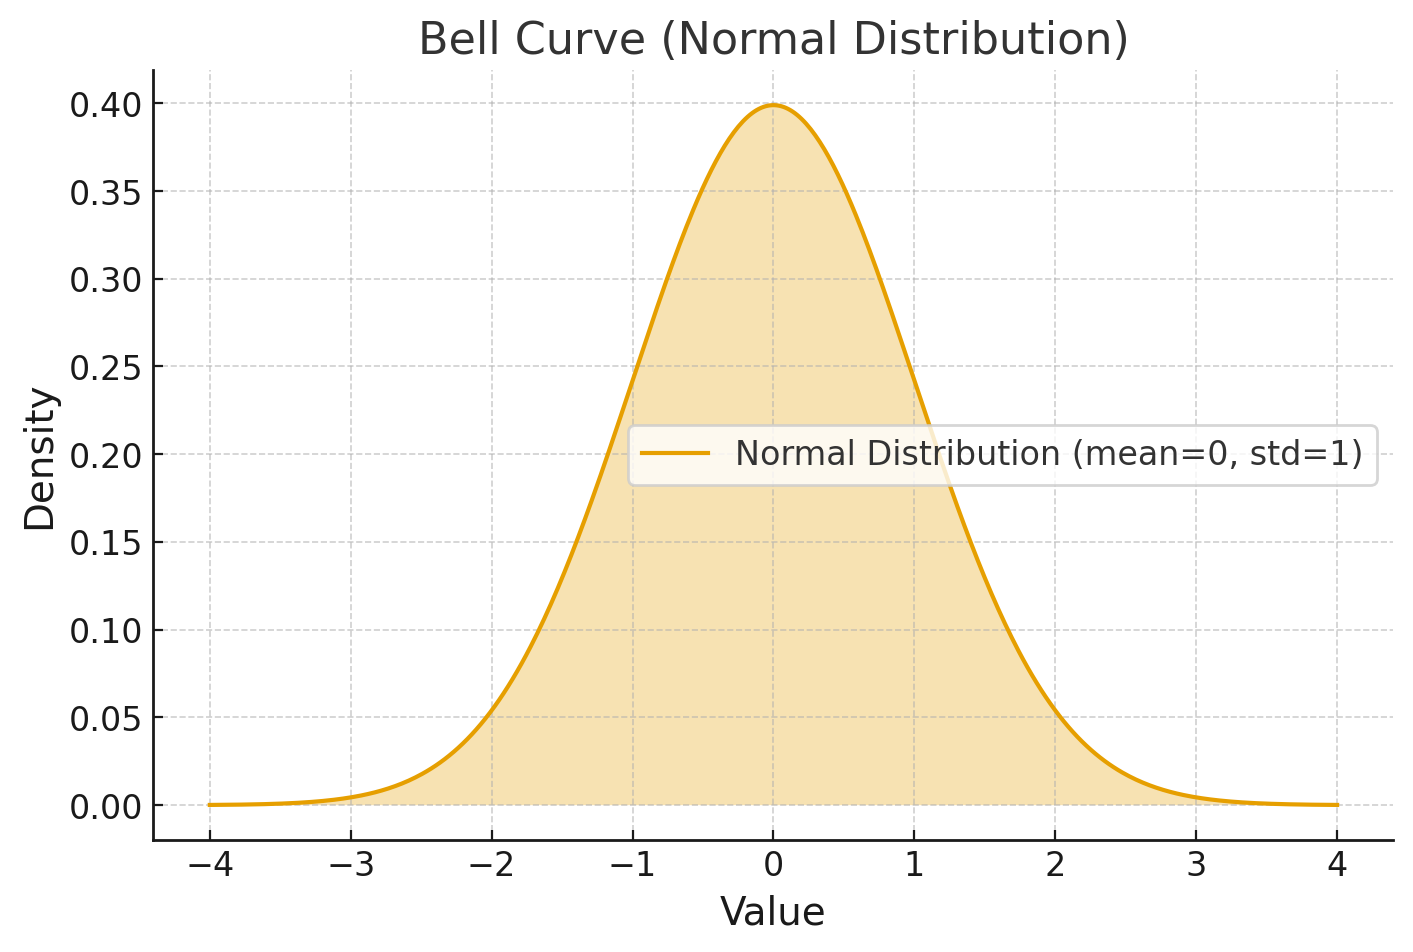

## 4. Cumulative Distribution Function (CDF)
- The CDF gives the probability that the random variable is **less than or equal** to some number.  
- Example: If $X$ is “height of a randomly chosen student,” then  

  $$
  F(170) = P(X \leq 170)
  $$  

  is the proportion of students who are 170 cm or shorter.  
- The CDF always starts at 0 and increases to 1 as you move rightward.

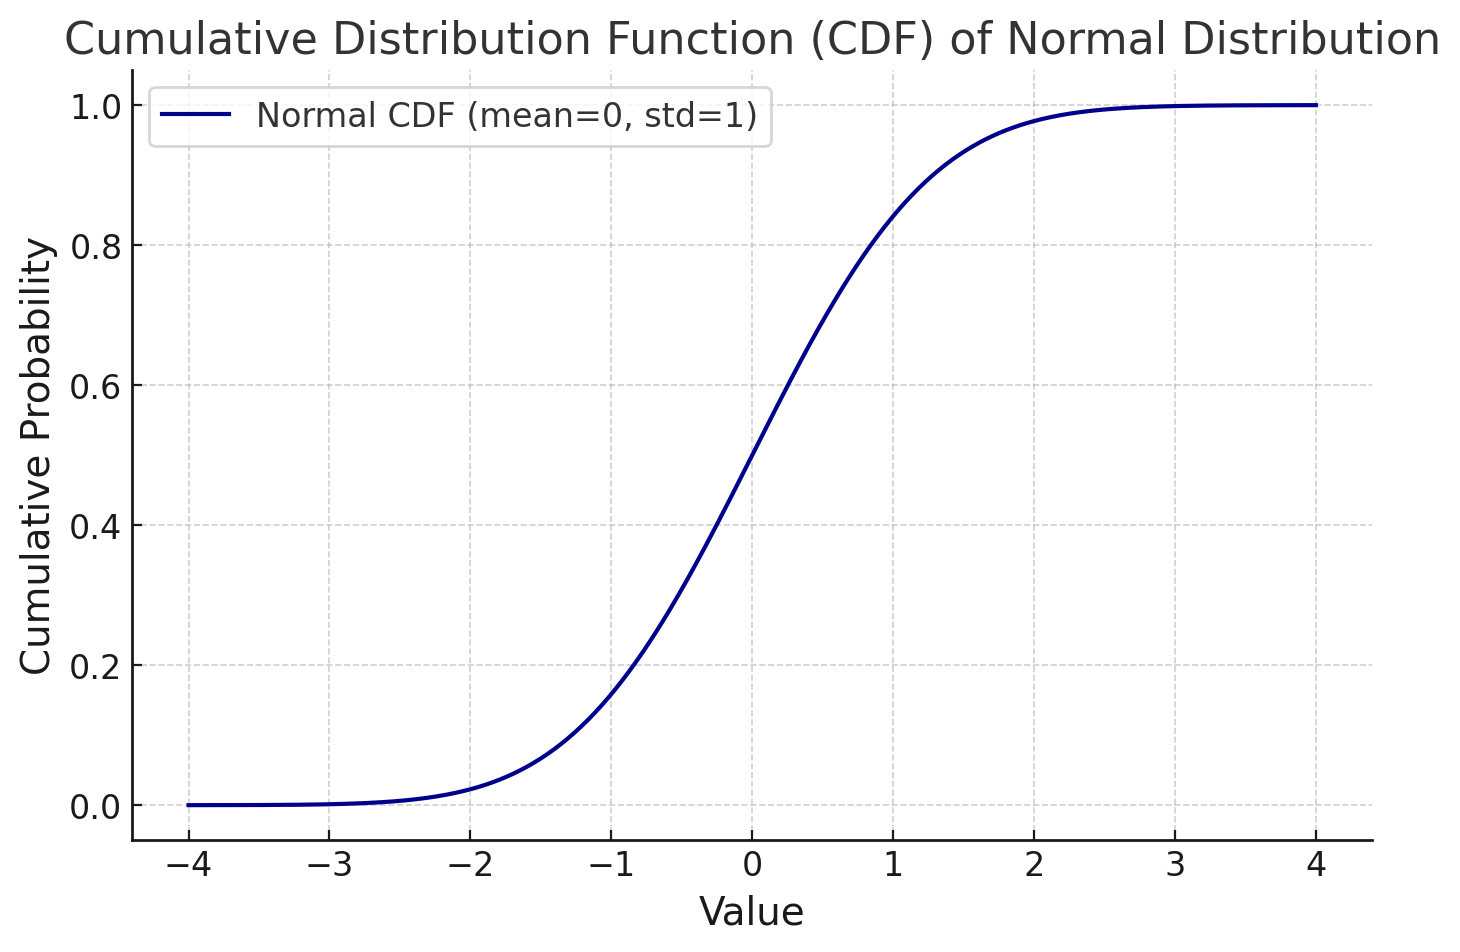

# Expectation, Variance, and Moments  

## 1. Expectation (Mean) and Linearity of Expectation
- The **expectation** (or mean) of a random variable $X$ is its long-run average value if the experiment is repeated many times (frequentist interpretation).  

- **Discrete case:**  

  $$
  E[X] = \sum_x x \cdot P(X = x)
  $$  

- **Continuous case:**  

  $$
  E[X] = \int_{-\infty}^{\infty} x \, f(x) \, dx
  $$

- **Example:** If you roll a fair die many times, the average outcome tends to 3.5.  

$$
E[X] = \sum_x x \cdot P(X = x) = 1 \times P(X=1) + 2 \times P(X=2) + 3 \times P(X=3) + 4 \times P(X=4) + 5 \times P(X=5) + 6 \times P(X=6) = 3.5
$$




- **Linearity of expectation:**  
  For any random variables $X, Y$ and constants $a, b$:

  $$
  E[aX + bY] = aE[X] + bE[Y].
  $$

  This holds even if $X$ and $Y$ are not independent.

- **Other Properties of expectation:**

  Let $X, Y$ be random variables and $a, b$ be constants

  - Expectation of a Constant

  $$
  E[c] = c
  $$

  - Shift by a Constant

  $$
  E[X + c] = E[X] + c
  $$

  - Multiplication by a Constant

  $$
  E[aX] = aE[X]
  $$

  - Expectation of a Sum is equal to the Sum of Expectations

  $$
  E\left[\sum_{i=1}^n X_i\right] = \sum_{i=1}^n E[X_i]
  $$

  - Product of Independent Variables

  If $X$ and $Y$ are **independent**:

  $$
  E[XY] = E[X] \cdot E[Y]
  $$

## 2. Variance

- The **deviation** measures the difference between a data point and the mean:

  $$
  \text{Deviation} = X - E[X]
  $$

- The **variance** measures average squared deviations (the expectation of $\text{Deviation}^2$) and can be calculated using the expectations $E[X]$ and $E[X^2]$:  

  $$
  \mathrm{Var}(X) \equiv E\big[(X - E[X])^2\big]
  $$

  ($\equiv$ means "defined as")  


- **Shortcut formula for variance**

  - Population Variance  

  $$
  \mathrm{Var}(X) = E[X^2] - (E[X])^2
  $$

  - Sample Variance

  $$
  s^2 = \frac{n}{n-1} [M_{X^2} - (M_{X})^2]
  $$

  Where $M_{X^2}$ is sample mean of $X^2$ and $M_{X}$ is sample mean of $X$

  - **These equations are often useful because it is usually easier to compute $E[X^2]$ and $E[X]$ or $M_{X^2}$ and $(M_{X})^2$ separately rather than working directly with $E[(X - E[X])^2]$**



- **Properties of Variance**

  - Non-Negativity

  $$
  \mathrm{Var}(X) \geq 0
  $$

  Variance is always non-negative, since it is the expectation of a squared quantity.

  - Scaling by a Constant

  $$
  \mathrm{Var}(aX) = a^2 \, \mathrm{Var}(X)
  $$

  - Adding a Constant

  $$
  \mathrm{Var}(X + b) = \mathrm{Var}(X)
  $$  

    (Adding a constant shifts the distribution but does not change its spread.)

  - Variance of a Sum

    - If $X$ and $Y$ are independent:

    $$
    \mathrm{Var}(X + Y) = \mathrm{Var}(X) + \mathrm{Var}(Y) \text{ (population)}
    $$

    or

    $$E[s_{X+Y}^2] = E[s_X^2] + E[s_Y^2] \text{ (sample)}$$

    - More generally (without independence):

    $$
    \mathrm{Var}(X + Y) = \mathrm{Var}(X) + \mathrm{Var}(Y) + 2\mathrm{Cov}(X, Y)
    $$

    Where $\mathrm{Cov}(X, Y)$ is the covariance between $X$ and $Y$ introduced in the next section



### Proof of the Variance Calculation (Population Variance)

We want to show:

$$
\mathrm{Var}(X) \equiv E[(X - E[X])^2] = E[X^2] - (E[X])^2
$$

#### Step 1. Expand the square

$$
(X - E[X])^2 = X^2 - 2X \cdot E[X] + (E[X])^2
$$

#### Step 2. Take expectation of both sides

$$
E[(X - E[X])^2] = E[X^2] - E[2X \cdot E[X]] + E[(E[X])^2]
$$

#### Step 3. Simplify terms on the right side
- Since $E[X]$ is a constant and use linearity of expectation:

$$E[2X \cdot E[X]] = 2E[X] \cdot E[X] = 2(E[X])^2$$  

$$E[(E[X])^2] = (E[X])^2$$  

(the expectation of a constant $E[X]$ is the constant itself)

Therefore

$$
E[(X - E[X])^2] = E[X^2] - 2(E[X])^2 + (E[X])^2
$$

$$
E[(X - E[X])^2] = E[X^2] - (E[X])^2
$$

### Conclusion

$$
\mathrm{Var}(X) = E[(X - E[X])^2] = E[X^2] - (E[X])^2
$$


## 3. Covariance & Correlation

- **Covariance:** Measures how two random variables vary together:

  $$
  \mathrm{Cov}(X, Y) ≡ E\big[(X - E[X])(Y - E[Y])\big]
  $$

  - Positive covariance → when $X$ is above average, $Y$ tends to be above average too.   

  - Negative covariance → when $X$ is above average, $Y$ tends to be below average.  

- **Population Covariance and Sample Covariance**

  - Population Covariance

    For two random variables $X$ and $Y$, the **population covariance** is defined as:

    $$
    \operatorname{Cov}(X, Y) = E\big[(X - \mu_X)(Y - \mu_Y)\big]
    $$

    Where
      - $\mu_X = E[X]$ is the population mean of $X$,  
      - $\mu_Y = E[Y]$ is the population mean of $Y$.  


  - Sample Covariance

    For a sample of size $n$ with pairs $(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)$, the **sample covariance** is:

    $$
    s_{XY} = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
    $$

    where  
      - $\bar{x} = \tfrac{1}{n}\sum_{i=1}^n x_i$ is the sample mean of $X$,  
      - $\bar{y} = \tfrac{1}{n}\sum_{i=1}^n y_i$ is the sample mean of $Y$.  

  The denominator $n-1$ is used (instead of $n$) so that $s_{XY}$ is an **unbiased estimator** of the population covariance.

- **Shortcut formula for covariance**

  - Population Covariance  

  $$
  \mathrm{Cov}(X, Y) = E[XY] - E[X]E[Y]
  $$

  - Sample Covariance

  $$
  s_{XY}
  = \frac{n}{n-1}\left(M_{XY} - M_X M_Y \right)
  $$

  Where $M_X$ is sample mean of $X$, $M_Y$ is sample mean of $Y$, and $M_{XY}$ is sample mean of $XY$.


  - **These equations are often useful because it is usually easier to compute $E[XY]$, $E[X]$, $E[Y]$, $M_{XY}$, $M_X$, $M_Y$ separately rather than working directly with $E\big[(X - E[X])(Y - E[Y])\big]$.**



- **Properties of Covariance:**

  - Variance as a special case:
  $$
  \mathrm{Var}(X) = \mathrm{Cov}(X, X)
  $$

  - Covariance is symmetric:

  $$
  \mathrm{Cov}(X, Y) = \mathrm{Cov}(Y, X)
  $$  

  - Independence:

    If $X$ and $Y$ are independent, then

    $$
    \mathrm{Cov}(X, Y) = 0 \text{ (population) and } E[s_{XY}] = 0 \text{ (sample) }
    $$

    **(But note: covariance = 0 does NOT imply independence!)**


- **Correlation:** A standardized version of covariance:  

  - Population Correlation  

    $$
    \rho_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{\sigma_X \sigma_Y}.
    $$

    Where  
      - $\operatorname{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$,  
      - $\sigma_X, \sigma_Y$ are the population standard deviations of $X$ and $Y$.

  - Sample Correlation

    $$
    r_{X,Y} = \frac{\mathrm{Cov}(X,Y)}{s_X s_Y}.
    $$

    Where  
      - $s_{XY} = \tfrac{1}{n-1} \sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})$ is the sample covariance,  
      - $s_X, s_Y$ are the sample standard deviations.

  **Examples of Correlation:**

  Height and weight usually have positive correlation.

  Ice cream sales and temperature also correlate positively.


# Different Probability Distributions

## Bernoulli Distribution

- **Definition**: Models a single trial with two possible outcomes: success (1) or failure (0).

  $$ P(X = 1) = p, \quad P(X = 0) = 1 - p, \quad X \sim \text{Bernoulli}(p). $$

- **Properties**:
  - Mean: $$ \mathbb{E}[X] = p $$
  - Variance: $$ \mathrm{Var}[X] = p(1 - p) $$

- **Relationships**:
  - **Building Block for Geometric**: A Geometric distribution is the number of Bernoulli trials until the first success.
  - **Building Block for Binomial**: A Binomial distribution is the sum of $n$ independent Bernoulli trials.


## Geometric Distribution

- **Definition**: Models the number of Bernoulli trials until the first success.

  $$ P(X = k) = (1 - p)^{k - 1} p, \quad k = 1, 2, 3, \dots, \quad X \sim \text{Geometric}(p). $$

- **Key Properties**:
  - Mean: $ \mathbb{E}[X] = \frac{1}{p} $
  - Variance: $ \mathrm{Var}[X] = \frac{1 - p}{p^2} $
  
- **Relationships**:
  - **Derived from Bernoulli**: The Geometric distribution is the number of Bernoulli trials needed to achieve the first success.
  - **Memoryless Property**: The Geometric distribution is memoryless:
    $$ P(X > k + m \mid X > k) = P(X > m). $$

## Binomial Distribution

- **Definition**: Models the number of successes in $n$ independent Bernoulli trials with success probability $p$.

  $$ P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}, \quad X \sim \text{Binomial}(n, p). $$

  Where

  \begin{align}
  \binom{n}{k} &= {\frac {n!}{k!(n-k)!}}
  \end{align}

  The term $\binom {n}{k}$ is the binomial coefficient.

- **Key Properties**:
  - Mean: $$ \mathbb{E}[X] = n p $$
  - Variance: $$ \mathrm{Var}[X] = n p (1 - p) $$

- **Relationships**:
  - **Sum of Bernoulli Trials**: A Binomial random variable is the sum of \(n\) independent Bernoulli random variables.
  - **Limit to Poisson**: For rare events $(p \to 0$ and $n \to \infty$ such that $n p = \lambda$):

    $$ \text{Binomial}(n, p) \to \text{Poisson}(\lambda). $$

### Create randomness

Numpy has many functions and capabilities related to randomness.  We can draw random numbers from various probability distributions. For example, to draw 5 uniform numbers between 0 and 100, you would use `np.random.uniform(0, 100, size = (5,))`.

 We will use `np.random.seed` to set a specific seed for the random number generator. For example, `np.random.seed(0)` sets the seed as 0. By including this, we are actually making the random numbers reproducible, which may seem odd at first. Basically if we do the below code without that 0, we would get different random numbers every time we run it. By setting the seed to 0, we ensure we will get the same random numbers. There are lots of reasons we may want randomness to be reproducible.

```python
np.random.seed(0)
random_nums = np.random.uniform(0, 100, size = (5,))
```


### Binomial Distribution for 1D Random walk of a rat

Stochastic models can be used to create models of behaviour.

As an example, imagine that a rat is placed inside a novel environment, a box.

We could try and model its exploration behaviour by assuming that for each time step it takes a random uniformly sampled step in any direction (only left or right)

### Binomial distribution sampling

We will draw a desired number of random samples from a binomial distribution, with $n = 10$ and $p = 0.5$.

Each sample returns the number of trials, $k$, a rat turns left out of $n$ trials.

We will draw 1000 samples of this (so it is as if we are observing 10 trials of the rat, 1000 different times). We can do this using numpy: `np.random.binomial(n, p, size = (n_samples,))`

See below to visualize a histogram of the different values of $k$, or the number of times the rat turned left in each of the 1000 samples.

In a histogram all the data is placed into bins and the contents of each bin is counted, to give a visualisation of the distribution of data.


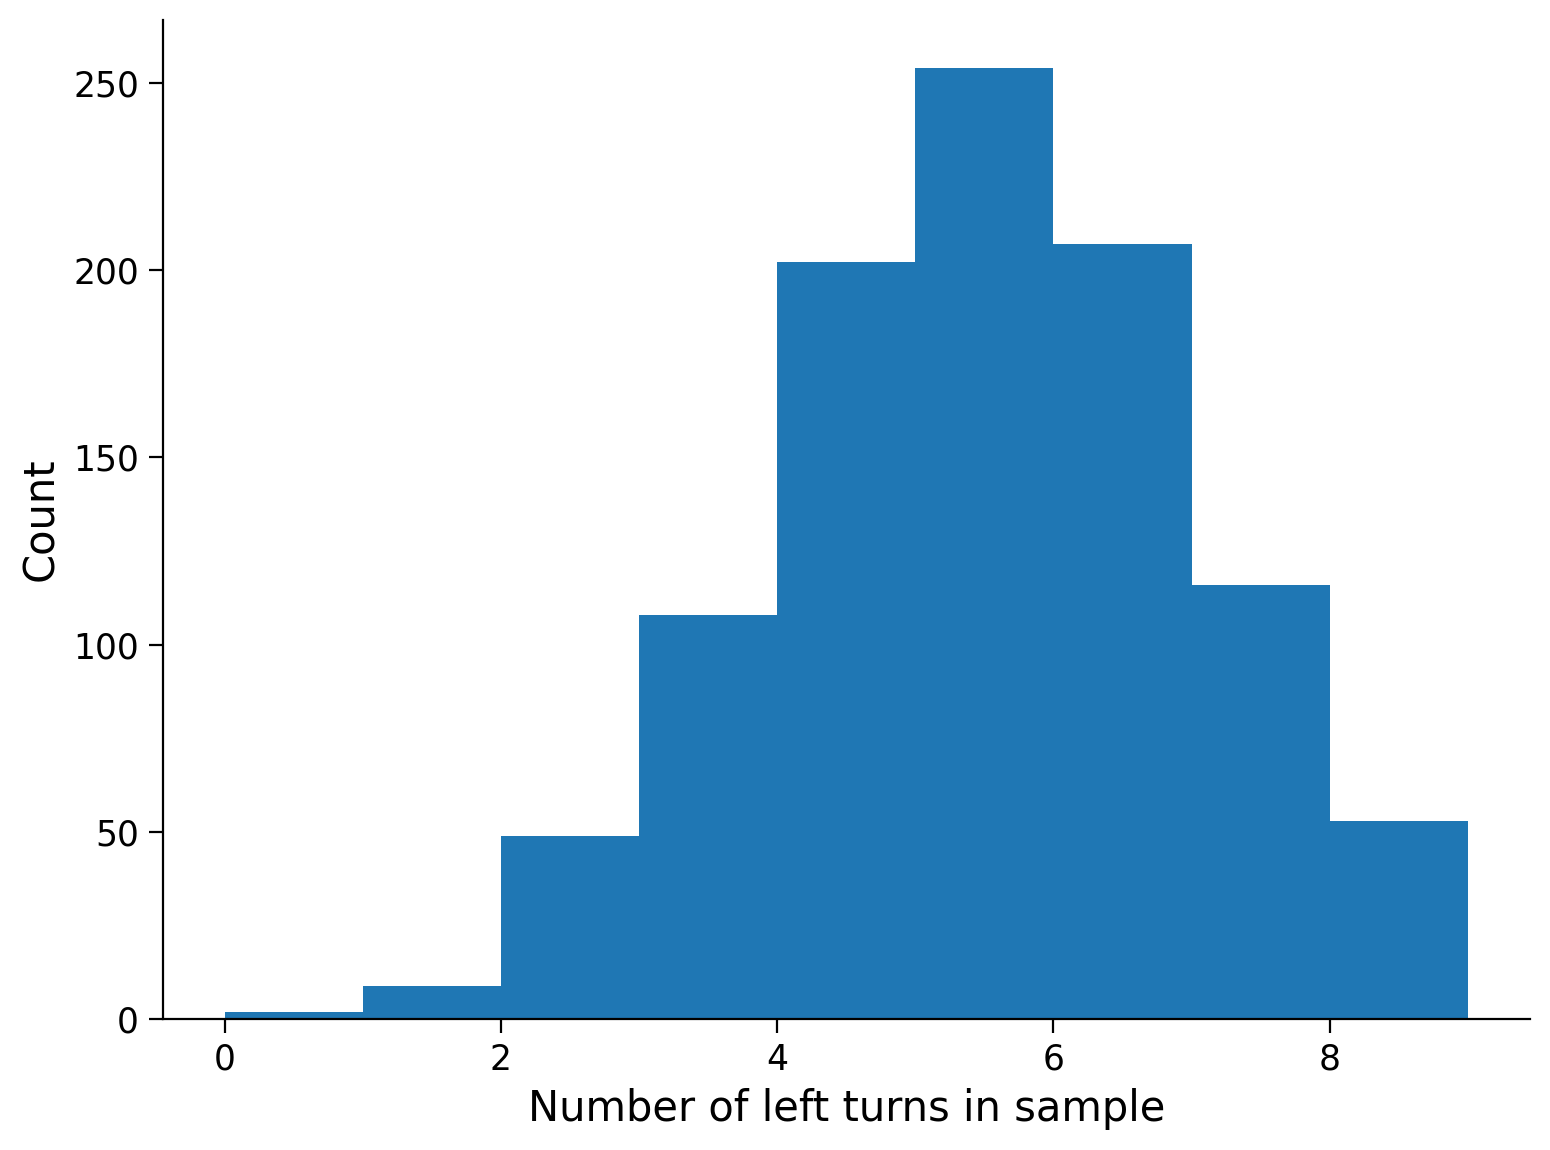

In [ ]:
# @markdown Execute this cell to see visualization

# Select parameters for conducting binomial trials
n = 10
p = 0.5
n_samples = 1000

# Set random seed
np.random.seed(1)

# Now draw 1000 samples by calling the function again
left_turn_samples_1000 = np.random.binomial(n, p, size = (n_samples,))

# Visualize
count, bins = plot_hist(left_turn_samples_1000, 'Number of left turns in sample')

## Multinomial distribution

When working with the Bernoulli and binomial distributions, there are only 2 possible outcomes (in the case of rat random walk, turn left or turn right).

In the more general case where there are $k$ possible outcomes (our rat can move in $k$ possible directions at each time) each with their own associated probability $p_1, p_2, p_3, p_4, ...$ , we use a **categorical distribution**.

Draws from this distribution are a simple extension of the Bernoulli trial:

we now have a probability for each outcome and draw based on those probabilities.

We have to make sure that the probabilities sum to one:

\begin{equation}
\sum_i P(x=i)=\sum_i p_i =1
\end{equation}

If we sample from this distribution multiple times, we can then describe the distribution of outcomes from each sample as the **multinomial distribution**.

Essentially, the categorical distribution is the multiple possible outcomes extension of the Bernoulli, and the multinomial distribution is the multiple outcomes extension of the binomial distribution.

- **Definition**:

  It generalizes the Binomial distribution to more than two categories.  

  It models the counts of outcomes in $n$ independent trials, each trial resulting in one of $k$ categories with probabilities $p_1, p_2, \dots, p_k$,  

  where $\sum_{i=1}^k p_i = 1$.

  $$ X_i = \text{the number of trials that the outcome is in category i}$$

  $$
  P(X_1 = x_1, \dots, X_k = x_k) =
  \frac{n!}{x_1! \, x_2! \cdots x_k!}
  \prod_{i=1}^k p_i^{x_i},
  \quad (X_1, \dots, X_k) \sim \text{Multinomial}(n, p_1, \dots, p_k).
  $$

  Subject to the constraint:

  $$
  \sum_{i=1}^k x_i = n
  $$

- **Properties**:

  - Mean:  
    $$
    \mathbb{E}[X_i] = n p_i
    $$
  - Variance:  
    $$
    \mathrm{Var}[X_i] = n p_i (1 - p_i)
    $$
  - Covariance (for $i \neq j$):  
    $$
    \mathrm{Cov}(X_i, X_j) = -n p_i p_j
    $$

- **Relationships**:

  - **Binomial as a Special Case**:  
    For $k = 2$, the Multinomial reduces to the Binomial distribution.  

  - **Connection to Categorical Distribution**:  
    The Multinomial counts outcomes from $n$ independent draws from a Categorical ($p_1, \dots, p_k$) distribution.  

  - **Limit to Multivariate Normal**:  
    For large $n$, the Multinomial can be approximated by a multivariate normal with matching mean vector and covariance matrix.




### Multinomial Distribution for 2D Random walk of a rat

We could try and model its exploration behaviour by assuming that for each time step it takes a random uniformly sampled step in more than 2 directions

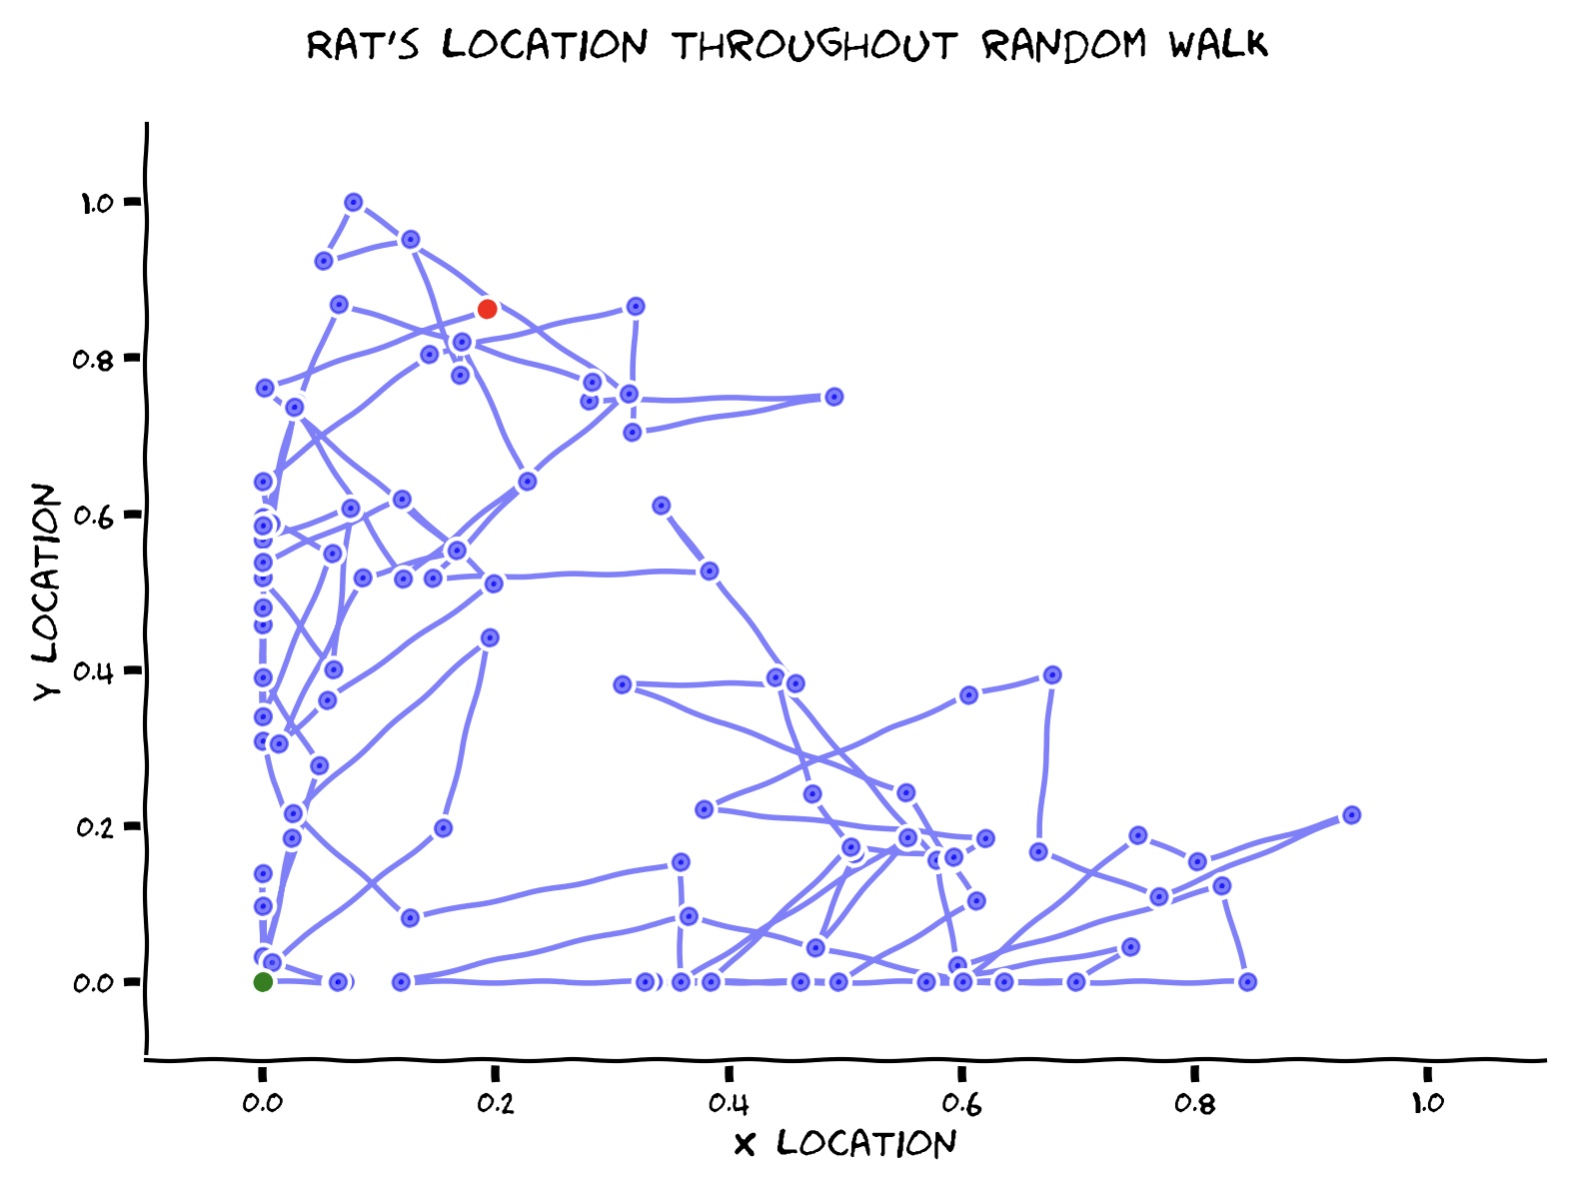

## Poisson Distribution

- **Definition**: Models the number of events in a fixed interval of time or space, assuming events occur independently and at a constant average rate $\lambda$.
  $$ P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad X \sim \text{Poisson}(\lambda). $$

- **Properties**:
  - Mean: $$ \mathbb{E}[X] = \lambda $$
  - Variance: $$ \mathrm{Var}[X] = \lambda $$
  - Sum of independent Poisson variables is still Poisson:
  
  if $X \sim \text{Poisson}(\lambda_1)$ and $Y \sim \text{Poisson}(\lambda_2)$, then $X + Y \sim \text{Poisson}(\lambda_1 + \lambda_2)$

- **Relationships**:
  - **Limit of Binomial**: The Poisson distribution is the limiting case of the Binomial distribution when $n \to \infty$ and $p \to 0$ (rare events).
  - **Counts in Poisson Process**: In a Poisson process, the Poisson distribution describes the number of events in a fixed interval.
  - **Exponential Connection**: The time between events in a Poisson process follows an Exponential distribution.

# Coding Exercise 2: Poisson distribution sampling

In the exercise below we will draw some samples from the Poisson distribution and see what the histogram looks.

In the code, fill in the missing line so we draw 5 samples from a Poisson distribution with $\lambda = 4$.

Use `np.random.poisson`.

In [ ]:

help(np.random.poisson)

Help on method poisson in module numpy.random.mtrand:

poisson(lam=1.0, size=None) method of numpy.random.mtrand.RandomState instance
    poisson(lam=1.0, size=None)

    Draw samples from a Poisson distribution.

    The Poisson distribution is the limit of the binomial distribution
    for large N.

    .. note::
        New code should use the `~numpy.random.Generator.poisson`
        method of a `~numpy.random.Generator` instance instead;
        please see the :ref:`random-quick-start`.

    Parameters
    ----------
    lam : float or array_like of floats
        Expected number of events occurring in a fixed-time interval,
        must be >= 0. A sequence must be broadcastable over the requested
        size.
    size : int or tuple of ints, optional
        Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
        ``m * n * k`` samples are drawn.  If size is ``None`` (default),
        a single value is returned if ``lam`` is a scalar. Otherwise,
        ``np.arra

In [ ]:
# Set random seed
np.random.seed(0)

# Draw 5 samples from a Poisson distribution with lambda = 4
sampled_spike_counts = np.random.poisson(4, 5)

# Print the counts
print("The samples drawn from the Poisson distribution are " +
          str(sampled_spike_counts))

The samples drawn from the Poisson distribution are [6 7 1 8 4]


You should see that the neuron spiked 6 times, 7 times, 1 time, 8 times, and 4 times in 5 different intervals.

### Interactive Demo: Varying parameters of Poisson distribution

Use the interactive demo below to vary $\lambda$ and the number of samples, and then visualize the resulting histogram.

In [ ]:
# @markdown Make sure you execute this cell to enable the widget!

@widgets.interact(lambda_value = widgets.FloatSlider(value=4, min=0.1, max=10, step=0.1),
                  n_samples = widgets.IntSlider(value=5, min=5, max=500, step=1))

def gen_and_plot_possion_samples(lambda_value, n_samples):
  sampled_spike_counts = np.random.poisson(lambda_value, n_samples)
  count, bins = plot_hist(sampled_spike_counts, 'Recorded spikes per second')

interactive(children=(FloatSlider(value=4.0, description='lambda_value', max=10.0, min=0.1), IntSlider(value=5…

# Question 2

1. What effect does increasing the number of samples have?  
2. What effect does changing $\lambda$ have?
3. With a small lambda, why is the distribution asymmetric?

What effect does increasing the number of samples have?

-- The histogram stablizes, hence it reveals the distribution/pattern and reduces noise.

What effect does changing  λ  have?

-- Increasing lambda, will make the distribution shift right in the center more of bell-shaped (normal distribution), the shape becomes more symmetric, which means the neuron is more active.

With a small lambda, why is the distribution asymmetric?

-- Because most spikes is accumulated at 0 and 1, higher counts become rare, and therefore it becommes skewed and asymmetric.

# Discussion Part 2

## Exponential Distribution

- **Definition**: Models the time interval between successive events in a Poisson process.
  $$ f(t) = \lambda e^{-\lambda t}, \quad t \geq 0, \quad T \sim \text{Exponential}(\lambda). $$

- **Key Properties**:
  - Mean: $$ \mathbb{E}[T] = \frac{1}{\lambda} $$
  - Variance: $$ \mathrm{Var}[T] = \frac{1}{\lambda^2} $$
  
- **Relationships**:
  - **Interarrival Times in Poisson Process**: The time between successive events in a Poisson process is Exponential.
  - **Memoryless Property**: The Exponential distribution is memoryless:
    $$ P(T > t + s \mid T > t) = P(T > s). $$

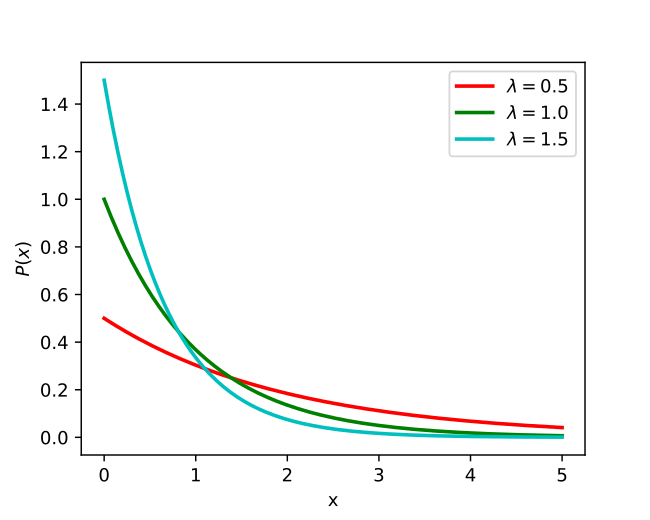

https://en.wikipedia.org/wiki/Exponential_distribution#/media/File:Exponential_distribution_pdf_-_public_domain.svg

## Gaussian (Normal) Distribution  

- **Definition**: Models continuous data that clusters symmetrically around a mean value. The Gaussian distribution is defined as:
  $$ f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right), \quad X \sim N(\mu, \sigma^2). $$
  Where:
  - $\mu$: Mean (center of the distribution),
  - $\sigma^2$: Variance (spread of the distribution).

- **Key Properties**:
  - Mean: $ \mathbb{E}[X] = \mu $
  - Variance: $ \mathrm{Var}[X] = \sigma^2 $
  - Symmetry: The Gaussian is symmetric around the mean $\mu$.
  - Infinite Support: Defined over $x \in (-\infty, \infty)$.
  
- **Relationships**:
  - **Central Limit Theorem**: The Gaussian distribution arises as the limiting distribution for the sum of a large number of independent, identically distributed random variables.
  - **Approximation for Binomial and Poisson**:
    - For large $n$, the Binomial distribution can be approximated by:
      $$ \text{Binomial}(n, p) \approx N(np, np(1-p)). $$
    - For large $\lambda$, the Poisson distribution can be approximated by:
      $$ \text{Poisson}(\lambda) \approx N(\lambda, \lambda). $$

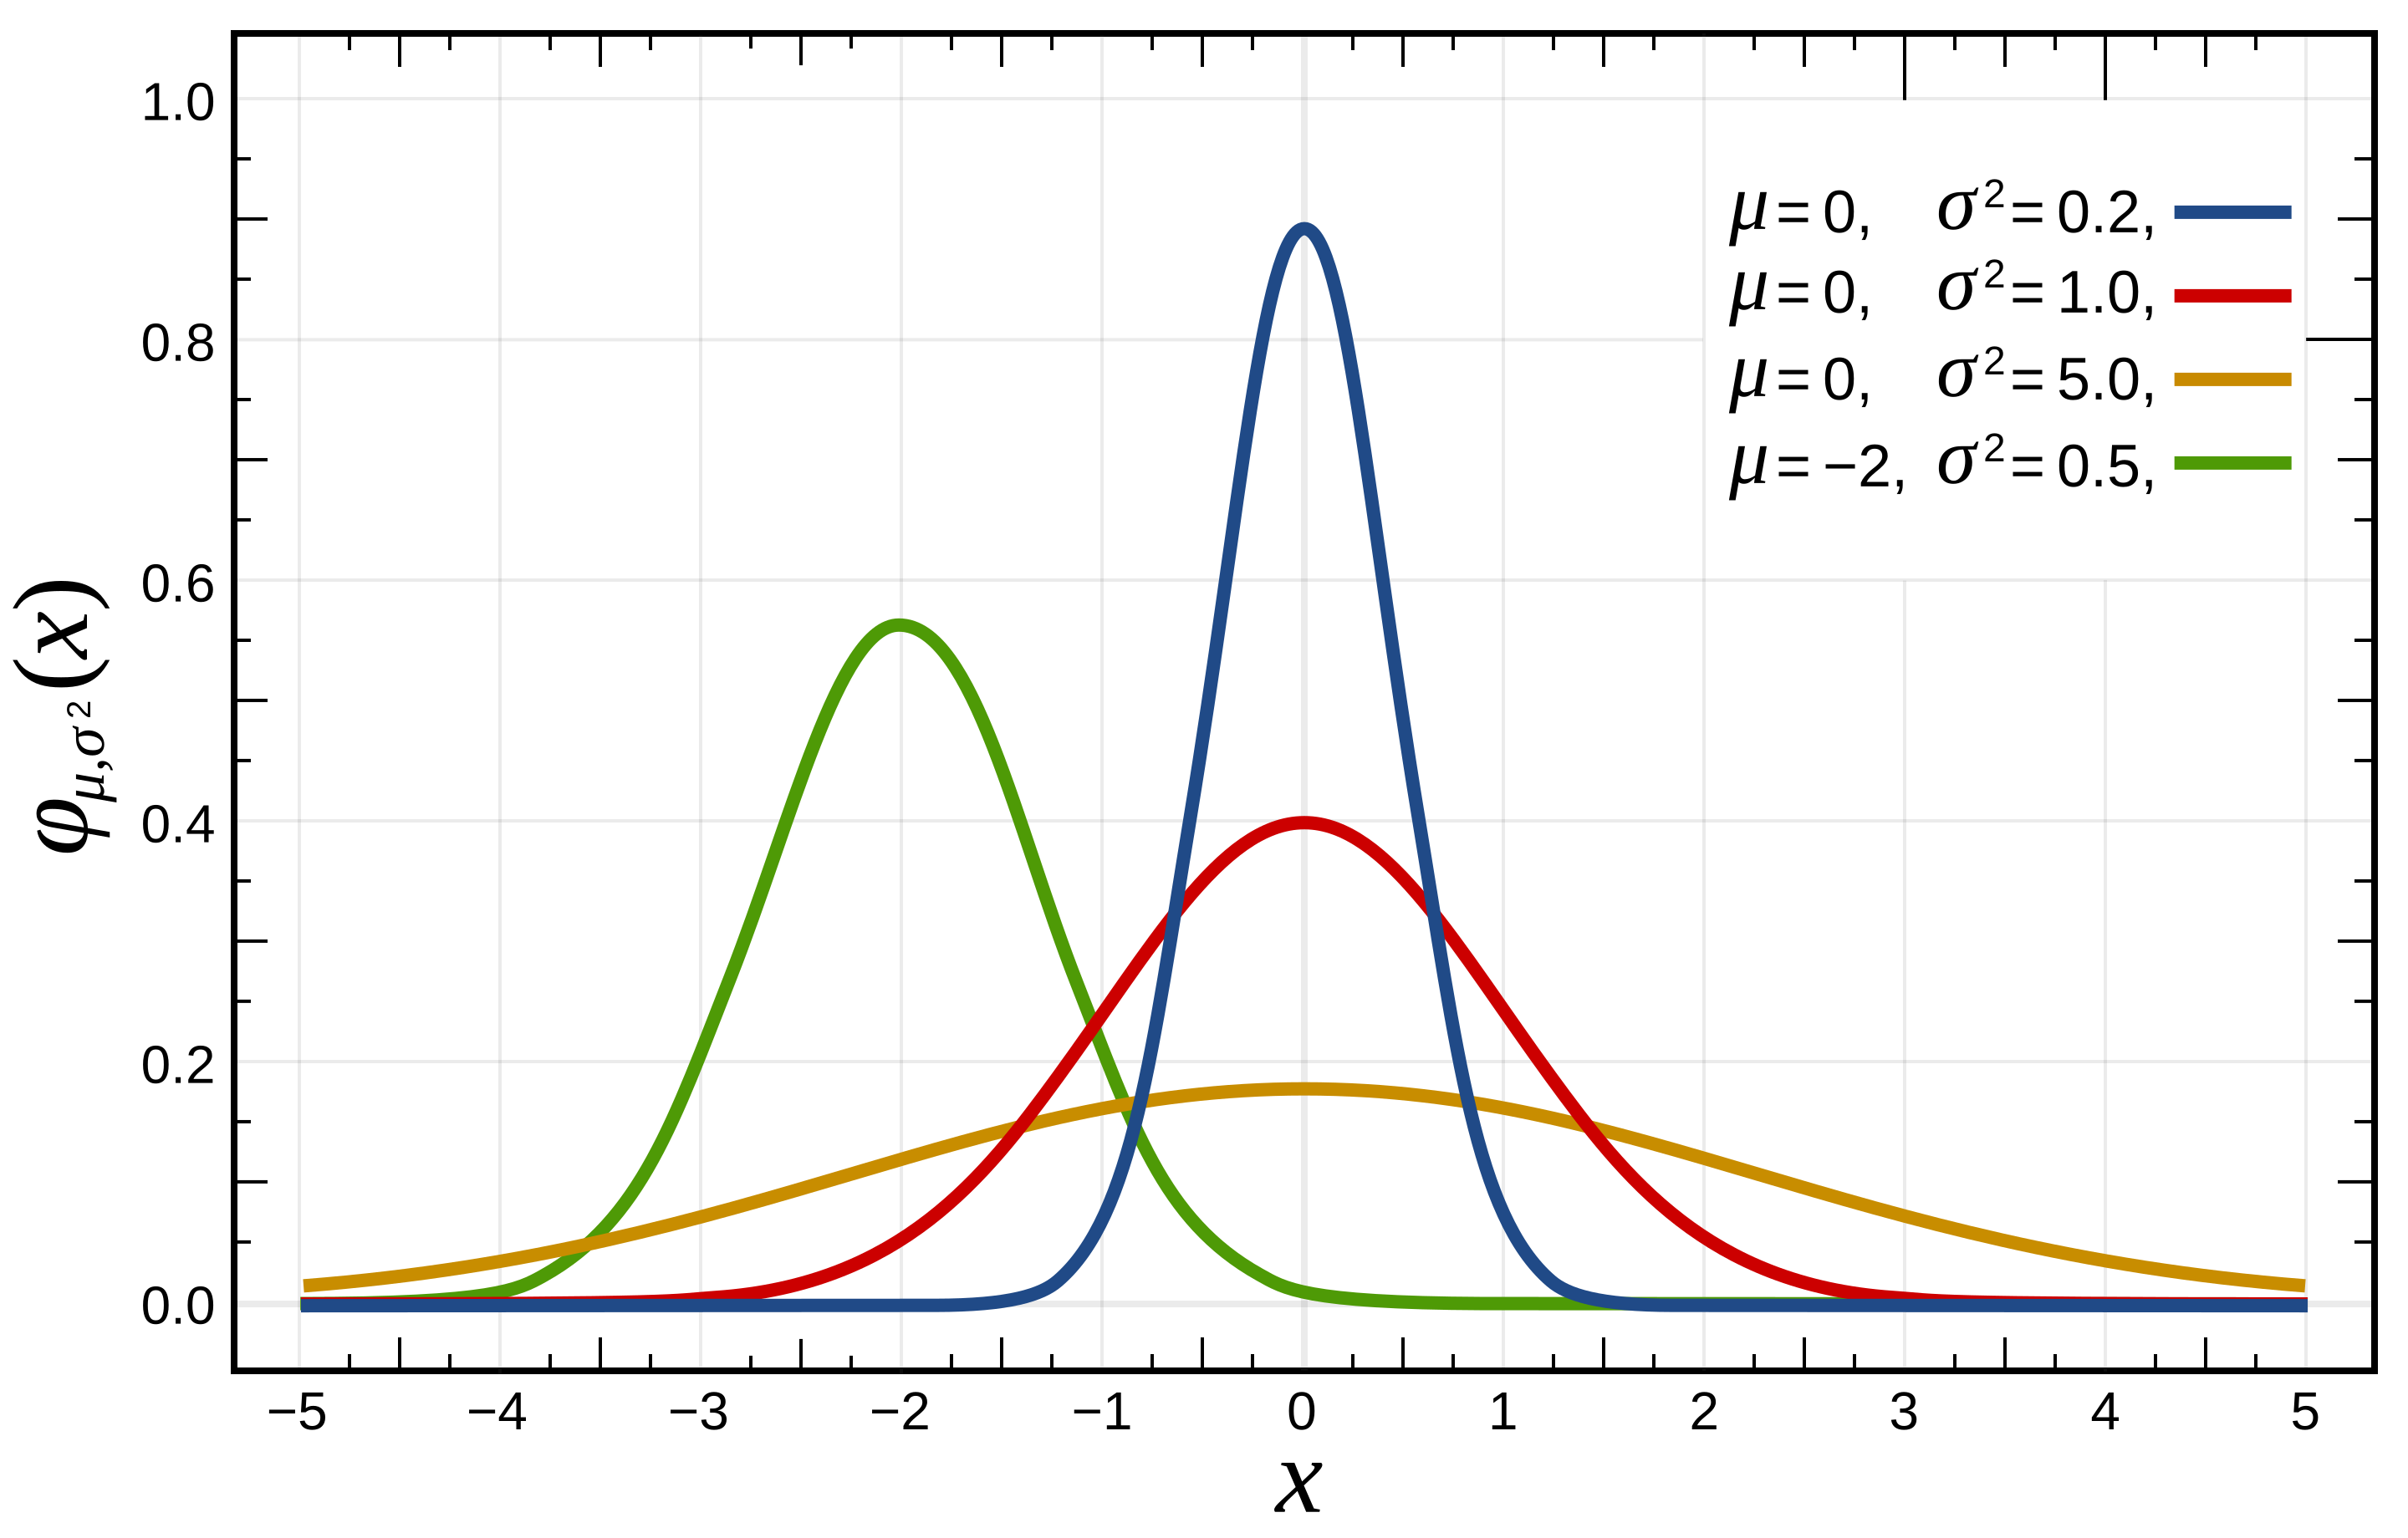

https://en.wikipedia.org/wiki/Normal_distribution#/media/File:Normal_Distribution_PDF.svg

# Coding Exercise 3: Gaussian Distribution

In this exercise, you will implement a Gaussian by filling in the missing portions of code for the function `my_gaussian` below.

Gaussians have two parameters.

The **mean** $\mu$, which sets the location of its center, and its "scale" or spread is controlled by its **standard deviation** $\sigma$, or **variance** $\sigma^2$ (i.e. the square of standard deviation).

**Be careful not to use one when the other is required.**

The equation for a Gaussian probability density function is:

\begin{equation}
f(x;\mu,\sigma^2) = N(\mu,\sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(\frac{-(x-\mu)^2}{2\sigma^2}\right)
\end{equation}

In Python $\pi$ and $e$ can be written as `np.pi` and `np.exp` respectively.

As a probability distribution this has an integral of one when integrated from $-\infty$ to $\infty$, however in the following your numerical Gaussian will only be computed over a finite number of points (for the cell below we will sample from -8 to 9 in step sizes of 0.1).

You therefore need to explicitly normalize it to sum to one by yourself.

Test out your implementation with a $\mu = -1$ and $\sigma = 1$.  

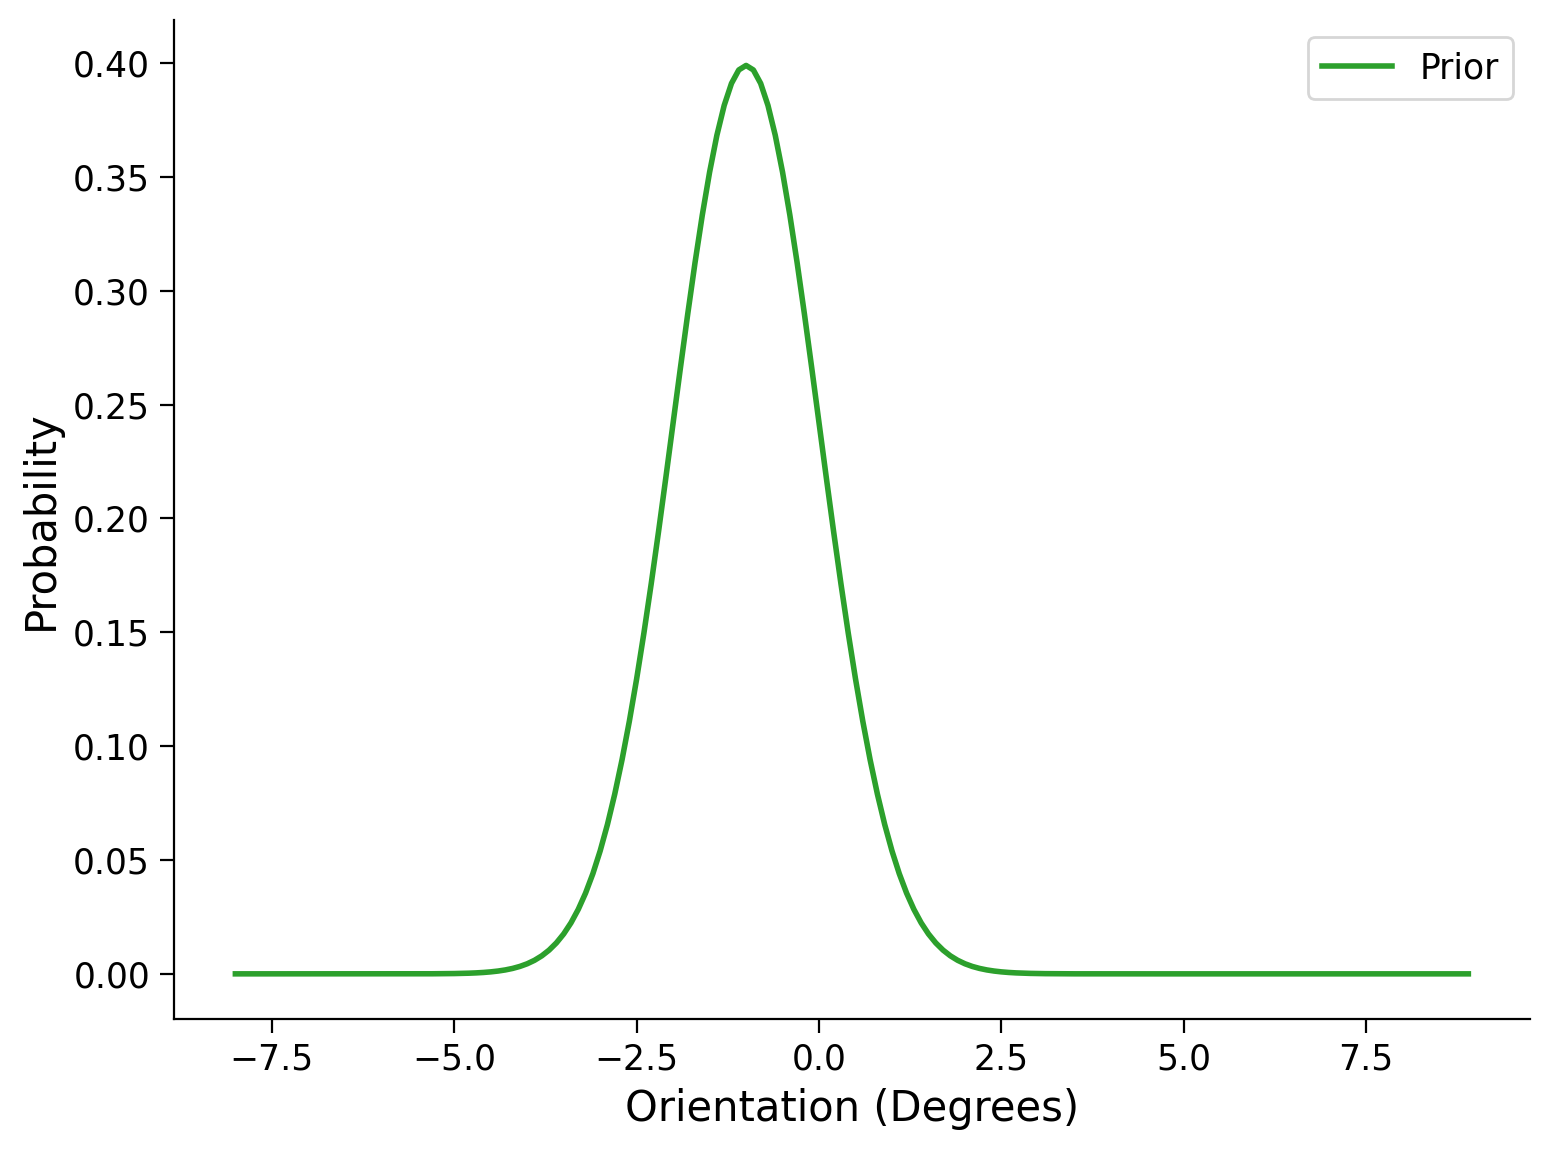

In [ ]:
def my_gaussian(x_points, mu, sigma):
  """ Returns normalized Gaussian estimated at points `x_points`, with
  parameters: mean `mu` and standard deviation `sigma`

  Args:
      x_points (ndarray of floats): points at which the gaussian is evaluated
      mu (scalar): mean of the Gaussian
      sigma (scalar): standard deviation of the gaussian

  Returns:
      (numpy array of floats) : normalized Gaussian evaluated at `x`
  """

  ###################################################################
  ## TODO for students: Implement the formula for a Gaussian
  ## Add code to calculate the gaussian px as a function of mu and sigma,
  ## for every x in x_points
  ## Function Hints: exp -> np.exp()
  ##                 power -> z**2
  ##
  ## Fill out the following then remove
  # raise NotImplementedError("Student exercise: need to implement Gaussian")
  ###################################################################
  px = np.exp(-(x_points-mu)**2/(2*sigma**2))
  px = px/(sigma*np.sqrt(2*np.pi))

  # as we are doing numerical integration we have to remember to normalise
  # taking into account the stepsize (0.1)
  px = px/(0.1*sum(px))
  return px

x = np.arange(-8, 9, 0.1)

# Generate Gaussian
px = my_gaussian(x, -1, 1)

# Visualize
my_plot_single(x, px)


*Example output:*

<img alt='Solution hint' align='left' width=777.0 height=577.0 src=https://raw.githubusercontent.com/NeuromatchAcademy/precourse/main/tutorials/W0D5_Statistics/static/W0D5_Tutorial1_Solution_2730515e_0.png>



### Interactive Demo: Sampling from a Gaussian distribution

Now that we have gained a bit of intuition about the shape of the Gaussian, let's imagine that a human participant is asked to point in the direction of a sound source, which we then measure in horizontal degrees.

To simulate that we draw samples from a Normal distribution:

\begin{equation}
x \sim N(\mu,\sigma)
\end{equation}

We can sample from a Gaussian with mean $\mu$ and standard deviation $\sigma$ using `np.random.normal(mu, sigma, size = (n_samples,))`.

In the demo below, you can change the mean and standard deviation of the Gaussian, and the number of samples, we can compare the histogram of the samples to the true analytical distribution (in red).


In [22]:
#@markdown Make sure you execute this cell to enable the widget!


@widgets.interact(mean = widgets.FloatSlider(value=0, min=-5, max=5, step=0.5),
                  standard_dev = widgets.FloatSlider(value=0.5, min=0, max=10, step=0.1),
                  n_samples = widgets.IntSlider(value=5, min=1, max=300, step=1))
def gen_and_plot_normal_samples(mean, standard_dev, n_samples):
  x = np.random.normal(mean, standard_dev, size = (n_samples,))
  xspace = np.linspace(-20, 20, 100)
  plot_gaussian_samples_true(x, xspace, mean, standard_dev,
                            'orientation (degrees)', 'probability')

interactive(children=(FloatSlider(value=0.0, description='mean', max=5.0, min=-5.0, step=0.5), FloatSlider(val…

## Summary of relationships between these distributions:

| **Distribution**      | **Relationship**                                                                                  |
|------------------------|------------------------------------------------------------------------------------------------------|
| **Bernoulli**          | Building block for Binomial and Geometric distributions.                                             |
| **Binomial**           | Sum of independent Bernoulli trials; approximates Poisson for rare events.                           |
| **Geometric**          | Number of Bernoulli trials until the first success; memoryless property.                             |
| **Poisson**            | Limit of Binomial for rare events; describes counts in a Poisson process.                            |
| **Exponential**        | Time between events in a Poisson process; related to Poisson through interarrival times.             |
| **Gaussian**           | Limit of sum of many independent random variables (Central Limit Theorem); approximates Binomial and Poisson for large parameters. |

## Entropy

### What does entropy mean? Why do we need the concept of entropy?

**Entropy can tell us the degree of our ignorance about a system.**

For example:

When we are flipping a coin, the coin could be a fair coin or a biased coin.

1. **Fair Coin (Maximal Ignorance)**

Probability of heads = 0.5

Probability of tails = 0.5

$$ H = -(0.5\log0.5 + 0.5\log0.5) = 1 \; bit $$

Interpretation: We have no prior knowledge favoring heads or tails, so our uncertainty (or ignorance) about the outcome is as large as it can be for two possibilities.

2. **Biased Coin (Less Ignorance)**

Probability of heads = 0.8

Probability of tails = 0.2

$$ H = -(0.2\log0.2 + 0.8\log0.8) ≈ 0.72 \; bits < 1 \; bit $$

Interpretation: Because heads is more likely, we have some knowledge of the outcome in advance. Our ignorance of the system is smaller than in the fair-coin case.

3. **Degenerate Case (No Ignorance)**

Probability of heads = 1.0

Probability of tails = 0.0

$$ H = -(0\log0 + 1\log1) = 0 \; bit $$

Interpretation: If the coin always comes up heads, we already know the result. There is zero uncertainty and we have no ignorance of the system, hence entropy is 0.

In order to calculate the entropy of probability distributions, Claude Shannon gives another mathematically equivalent definition of entropy:

$$H = -\sum_{i=1}^n p(x_i) \log p(x_i) = -\int_{-\infty}^\infty f(x) \log f(x) \, dx \text{   (Shannon entropy)}$$

Where $H$ is entropy,

$p(x_i)$ is the probability of the i-th outcome of random variable $X$, (when probability distribution is discrete)

$n$ is the number of possible outcomes, (when probability distribution is discrete)

$f(x)$ is the probability density function (PDF) of random variable $X$.  (when probability distribution is continuous)  


The base of the logarithm in entropy can have many different choices. It is usually $e$ in physics, and it is usually 2 in many other areas including information theory and computational neuroscience.




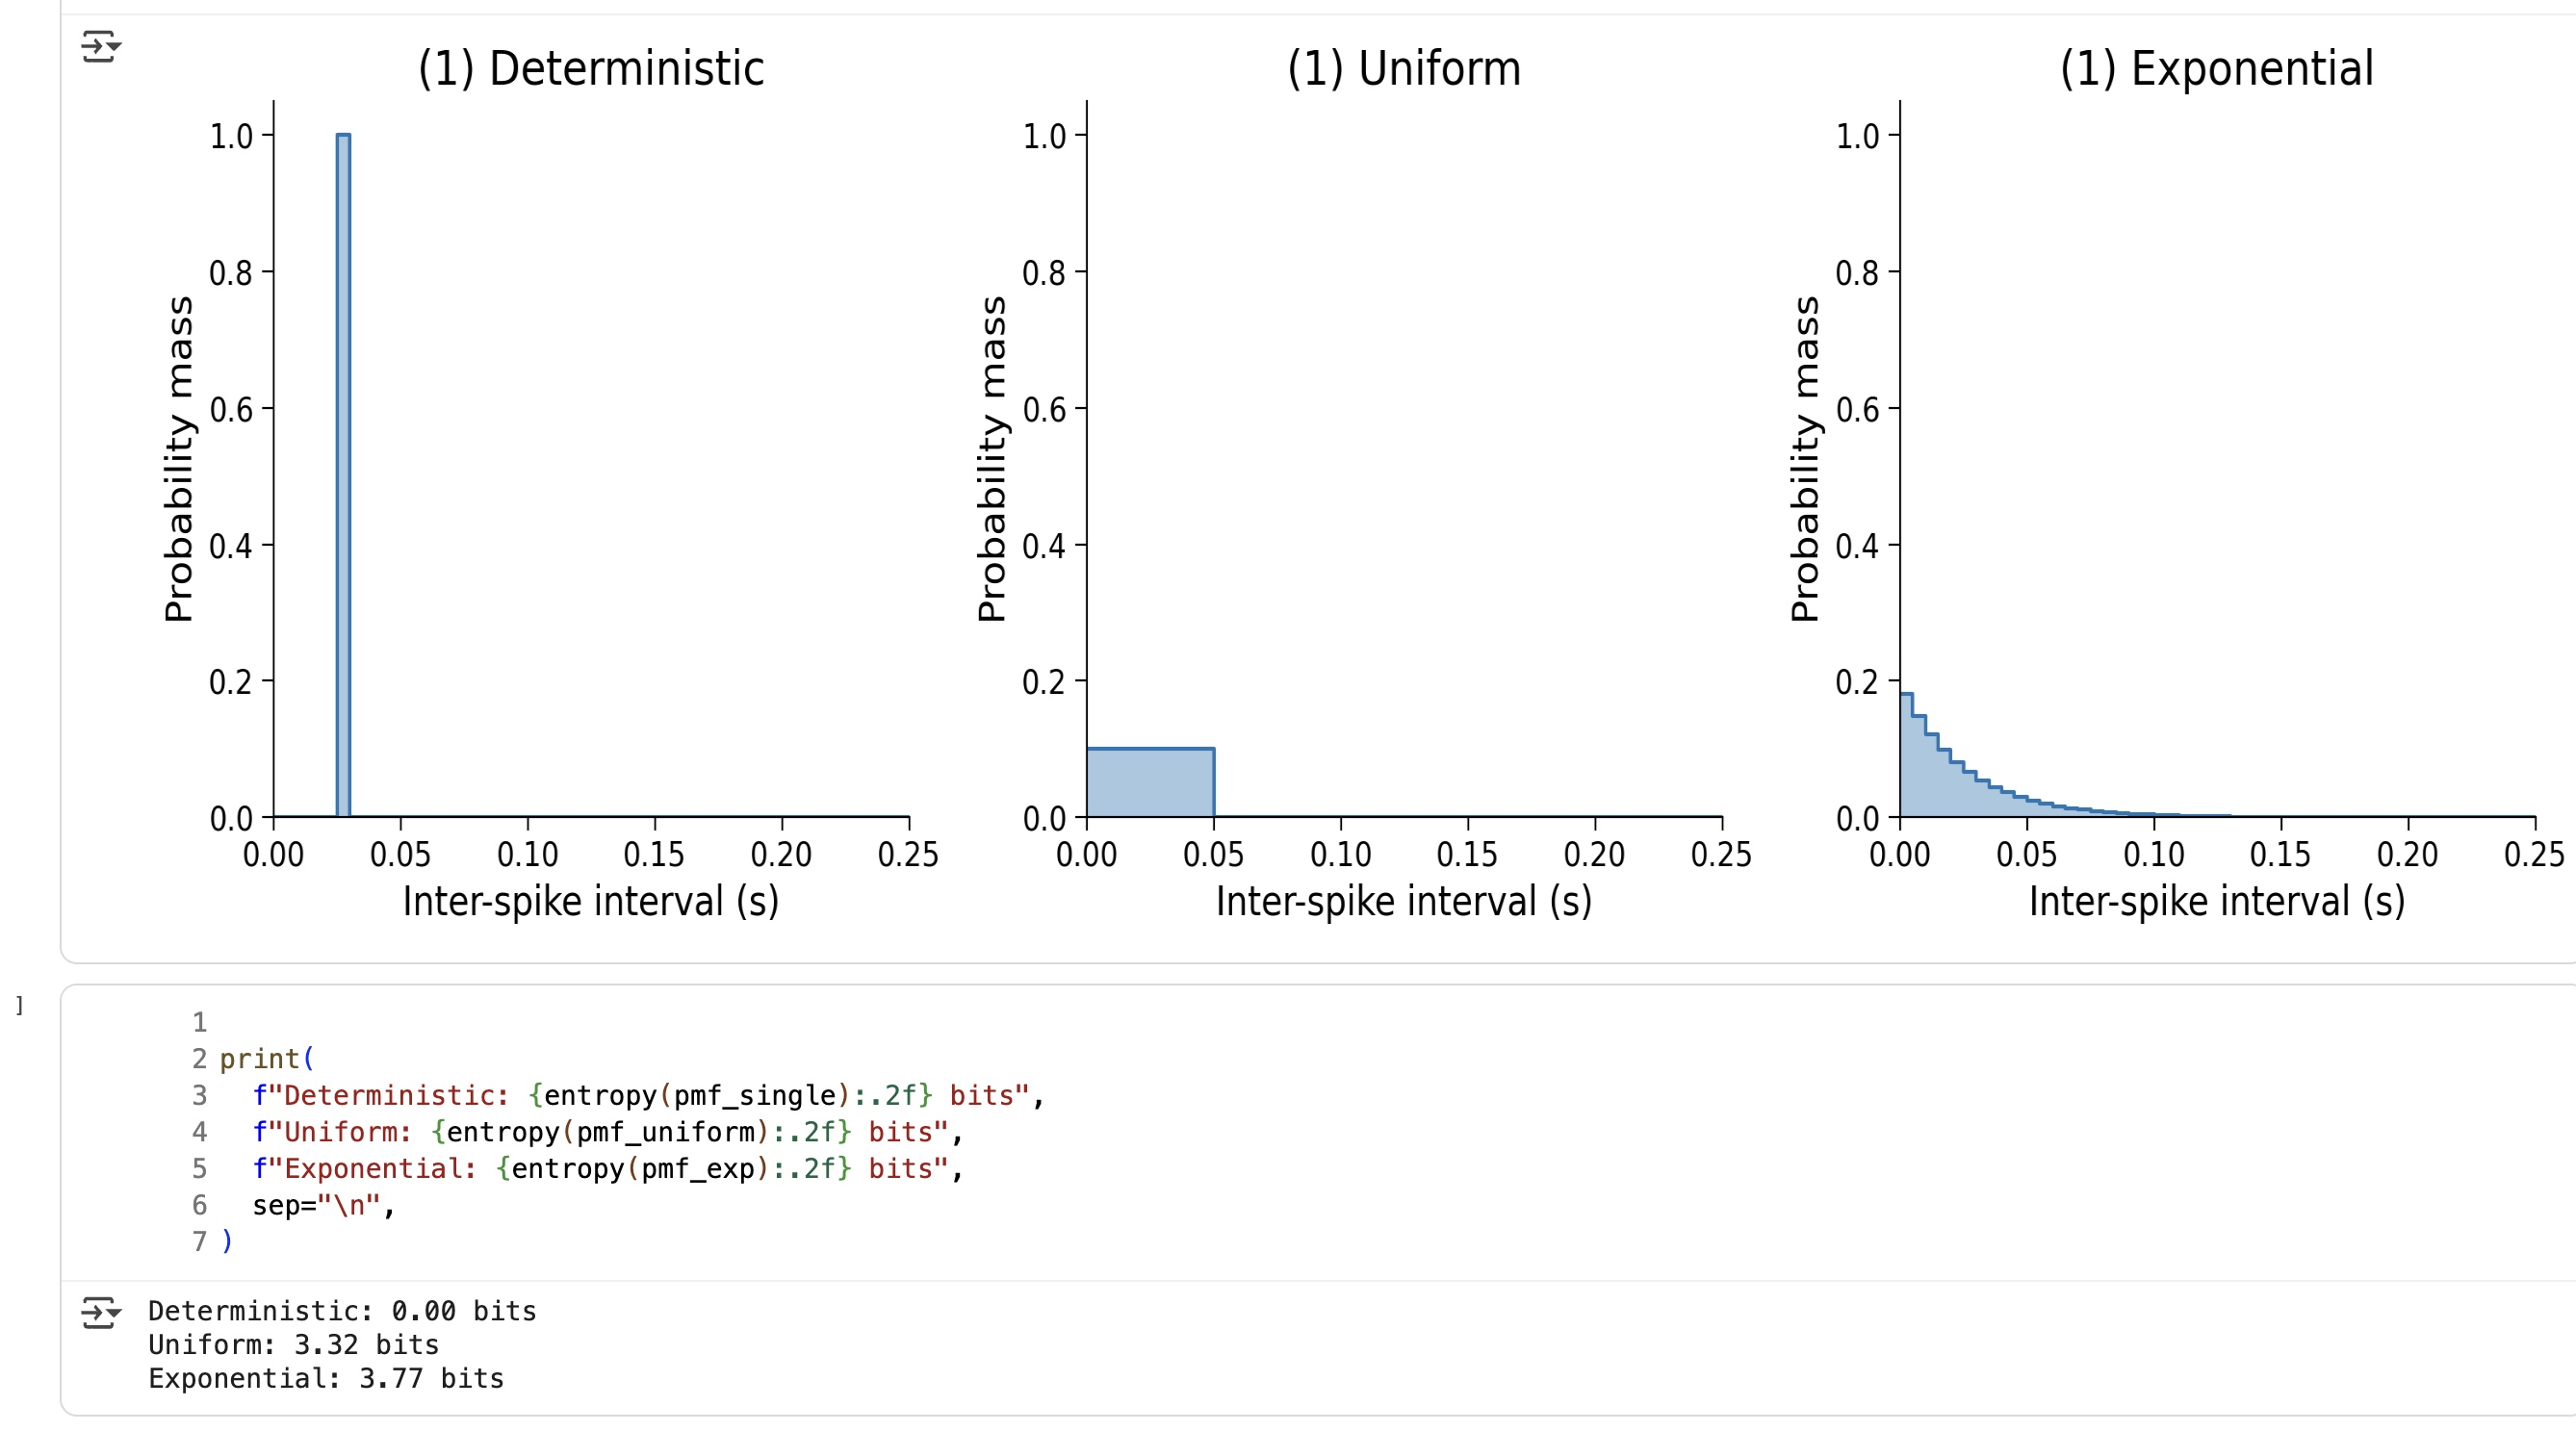

## The maximum entropy principle

The Maximum Entropy Principle in statistics is a fundamental concept used to derive probability distributions based on limited information while making the fewest assumptions about the unknown data.

It states that, among all possible probability distributions that satisfy the given constraints, the type of the random variable (discrete or continuous), and the support (e.g., positive or nonnegative), the distribution with the maximum entropy should be chosen because it is the least biased representation of the available information.

## Table of probability distributions and corresponding maximum entropy constraints

| **Distribution name** | **Probability density / mass function**                               | **Maximum Entropy constraint**                  | **Support**                     |
|------------------------|----------------------------------------------------------------------|-----------------------------------------------|---------------------------------|
| Uniform (discrete)     | $f(k) = \frac{1}{b - a + 1}$                                         | None                                           | $\{a, a+1, \dots, b-1, b\}$     |
| Uniform (continuous)   | $f(x) = \frac{1}{b - a}$                                             | None                                           | $[a, b]$                        |
| Bernoulli              | $f(k) = p^k (1-p)^{1-k}$                                             | $\mathbb{E}[K] = p$                            | $\{0, 1\}$    |
| Geometric              | $f(k) = (1-p)^{k-1} p$                                               | $\mathbb{E}[K] = \frac{1}{p}$                  | $\mathbb{N} \setminus \{0\}$    |                   
| Binomial               | $f(k) = \binom{n}{k} p^k (1-p)^{n-k}$                                | $\mathbb{E}[X] = n p$                          | $\{0, \dots, n\}$               |
| Poisson                | $f(k) = \frac{\lambda^k e^{-\lambda}}{k!}$                           | $\mathbb{E}[X] = \lambda$                      | $\mathbb{N} = \{0, 1, \dots\}$  |
| Exponential            | $f(x) = \lambda \exp(-\lambda x)$                                    | $\mathbb{E}[X] = \frac{1}{\lambda}$            | $[0, \infty)$                   |
| Normal                 | $f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$ | $\mathbb{E}[X] = \mu, \mathbb{Var}[X] = \sigma^2$ | $(-\infty, \infty)$             |




# Statistical Inference

## Likelihoods

In generative modeling, we start with a probability distribution (e.g., Gaussian) defined by parameters such as the mean $\mu$ and standard deviation $\sigma$.

This model allows us to make predictions about possible outcomes.  

---

### Likelihood for a Single Data Point
Given a parameterized model, the probability of observing a single data point $x_i$ is:

$$
P(x_i \mid \mu, \sigma) = N(x_i \mid \mu, \sigma)
$$

This represents the probability density of $x_i$ under a normal distribution with parameters $\mu, \sigma$.

---

### Likelihood for the Whole Dataset

For multiple independent observations $\mathbf{x} = (x_1, x_2, \dots, x_n)$,  

the likelihood of the dataset is the product of the individual probabilities:

$$
P(\mathbf{x} \mid \mu, \sigma) = \prod_{i=1}^n N(x_i \mid \mu, \sigma)
$$

---

### Likelihood Function

Although written as a conditional probability, we often use a different notation:

$$
L(\mu, \sigma) = P(\mathbf{x} \mid \mu, \sigma)
$$

This highlights the shift in perspective:
- The data $\mathbf{x}$ is **fixed** (already observed).  
- The parameters $\mu, \sigma$ are **unknown** and treated as variables of the likelihood function.

---

### Log-Likelihood Function

$$
l(\mu, \sigma) = Log\left[\prod_{i=1}^n N(x_i \mid \mu, \sigma)\right] = \sum_{i=1}^n Log[N(x_i \mid \mu, \sigma)]
$$

---

### Statistical Inference
- The goal is to find parameter values $(\mu, \sigma)$ that make the observed data **most likely**.  
- This process is called **statistical inference**.  
- A common method is **Maximum Likelihood Estimation (MLE)**, which selects parameter values that maximize $L(\mu,\sigma)$.  

---

In summary:  
- Probability distributions generate data given parameters.  
- Likelihood functions estimate these parameters given data.


### Coding Exercise 4: Computing likelihood

Let's start with computing the likelihood of some set of data points being drawn from a Gaussian distribution with a mean and variance we choose.

As multiplying small probabilities together can lead to very small numbers, it is often convenient to report the *logarithm* of the likelihood.

This is just a convenient transformation and as logarithm is a monotonically increasing function this does not change what parameters maximize the function.

In [ ]:
from scipy.stats import norm
import numpy as np

def compute_likelihood_normal(x, mean_val, standard_dev_val):
  """ Computes the log-likelihood values given a observed data sample x, and
  potential mean and variance values for a normal distribution

    Args:
      x (ndarray): 1-D array with all the observed data
      mean_val (scalar): value of mean for which to compute likelihood
      standard_dev_val (scalar): value of variance for which to compute likelihood

    Returns:
      likelihood (scalar): value of likelihood for this combination of means/variances
  """

  ###################################################################
  ## TODO for student
  # raise NotImplementedError("Student exercise: compute likelihood")
  ###################################################################

  # Get probability of each data point (use norm.pdf from scipy stats)
  p_data = norm.pdf(x, loc=mean_val, scale=standard_dev_val)

  # Compute likelihood (sum over the log of the probabilities)
  likelihood = np.sum(np.log(p_data))

  return likelihood

# Set random seed
np.random.seed(0)

# Generate data
true_mean = 5
true_standard_dev = 1
n_samples = 1000
x = np.random.normal(true_mean, true_standard_dev, size = (n_samples,))

# Compute likelihood for a guessed mean/standard dev
guess_mean = 4
guess_standard_dev = .1
likelihood = compute_likelihood_normal(x, guess_mean, guess_standard_dev)
print(likelihood)

-92904.81398544145


You should get a likelihood of `-92904.81`.

This is somewhat meaningless to us!

For it to be useful, we need to compare it to the likelihoods computing using other guesses of the mean or standard deviation.

The visualization below shows us the likelihood for various values of the mean and the standard deviation.

Essentially, we are performing a rough grid-search over means and standard deviations.  

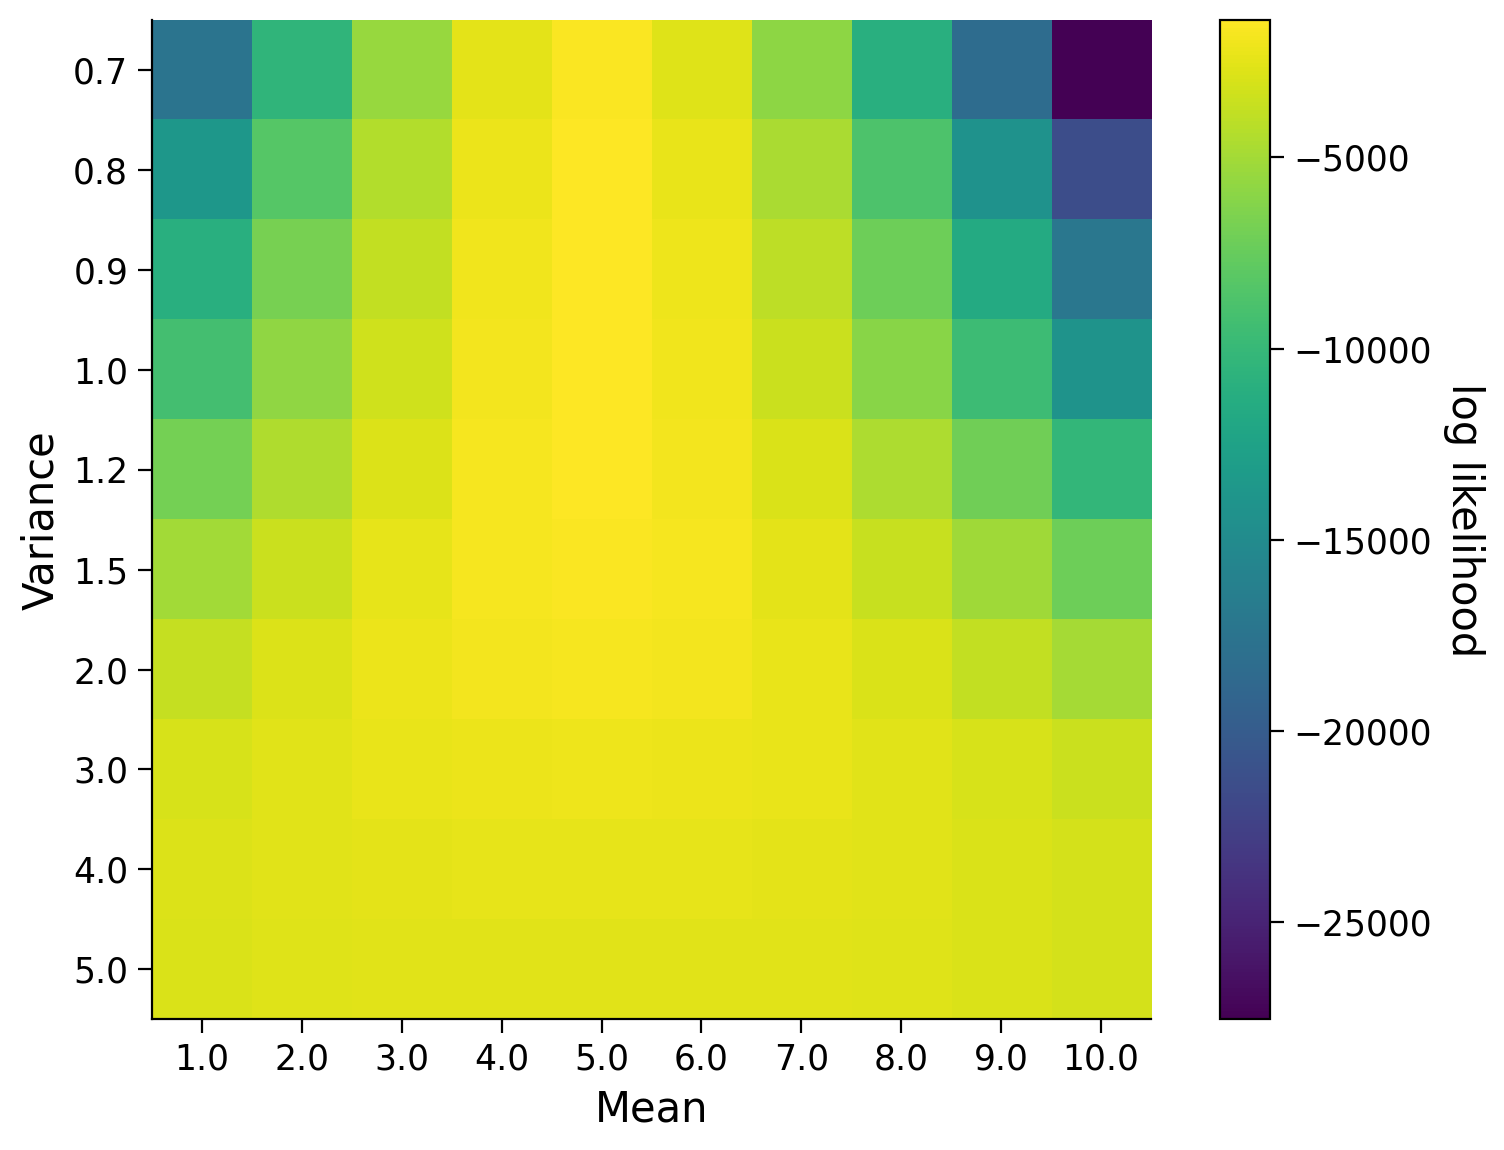

In [ ]:
# @markdown Execute to visualize likelihoods

# Set random seed
np.random.seed(0)

# Generate data
true_mean = 5
true_standard_dev = 1
n_samples = 1000
x = np.random.normal(true_mean, true_standard_dev, size = (n_samples,))


# Compute likelihood for different mean/variance values
mean_vals = np.linspace(1, 10, 10) # potential mean values to ry
standard_dev_vals = np.array([0.7, 0.8, 0.9, 1, 1.2, 1.5, 2, 3, 4, 5]) # potential variance values to try

# Initialise likelihood collection array
likelihood = np.zeros((mean_vals.shape[0], standard_dev_vals.shape[0]))

# Compute the likelihood for observing the gvien data x assuming
# each combination of mean and variance values
for idxMean in range(mean_vals.shape[0]):
  for idxVar in range(standard_dev_vals .shape[0]):
    likelihood[idxVar,idxMean]= sum(np.log(norm.pdf(x, mean_vals[idxMean],
                                              standard_dev_vals[idxVar])))

# Uncomment once you've generated the samples and compute likelihoods
xspace = np.linspace(0, 10, 100)
plot_likelihoods(likelihood, mean_vals, standard_dev_vals)

# Question 3

What would you guess as the true mean and standard deviation based on this visualization?

-- True Mean is around 5 and Standard Deviation is around 1 to 1.5

## Maximum likelihood


Implicitly, by looking for the parameters that give the highest likelihood in the last section, we have been searching for the **maximum likelihood** estimate.

\begin{equation}
(\hat{\mu},\hat{\sigma}) = \underset{\mu,\sigma}{\operatorname{argmax}}L(\mu,\sigma) = \underset{\mu,\sigma}{\operatorname{argmax}} \prod_{i=1}^n N(x_i,\mu,\sigma).
\end{equation}

In next sections, we will look at other ways of inferring such parameter variables.

### Searching for best parameters

We want to do inference on this data set, i.e. we want to infer the parameters that most likely gave rise to the data given our model.

Intuitively that means that we want as good as possible a fit between the observed data and the probability distribution function with the best inferred parameters.

We can search for the best parameters manually by trying out a bunch of possible values of the parameters, computing the likelihoods, and picking the parameters that resulted in the highest likelihood.

#### Interactive Demo: Maximum likelihood inference

Try to see how well you can fit the probability distribution to the data by using the demo sliders to control the mean and standard deviation parameters of the distribution. We will visualize the histogram of data points (in blue) and the Gaussian density curve with that mean and standard deviation (in red). Below, we print the log-likelihood.


In [ ]:
# @markdown Make sure you execute this cell to enable the widget and fit by hand!
# Generate data
true_mean = 5
true_standard_dev = 1
n_samples = 1000
vals = np.random.normal(true_mean, true_standard_dev, size = (n_samples,))

def plotFnc(mu,sigma):
  loglikelihood= sum(np.log(norm.pdf(vals,mu,sigma)))
  #calculate histogram

  #prepare to plot
  fig, ax = plt.subplots()
  ax.set_xlabel('x')
  ax.set_ylabel('probability')

  #plot histogram
  count, bins, ignored = plt.hist(vals,density=True)
  x = np.linspace(0,10,100)

  #plot pdf
  plt.plot(x, norm.pdf(x,mu,sigma),'r-')
  plt.show()
  print("The log-likelihood for the selected parameters is: " + str(loglikelihood))

#interact(plotFnc, mu=5.0, sigma=2.1);
#interact(plotFnc, mu=widgets.IntSlider(min=0.0, max=10.0, step=1, value=4.0),sigma=widgets.IntSlider(min=0.1, max=10.0, step=1, value=4.0));
interact(plotFnc, mu=(0.0, 15.0, 0.1),sigma=(0.1, 5.0, 0.1));

interactive(children=(FloatSlider(value=7.5, description='mu', max=15.0), FloatSlider(value=2.5000000000000004…

# Question 4

1. What (approximate) values of mu and sigma result in the best fit?

-- Values: mu of 5.10 and sigma of 1.00

2. How does the value below the plot (the log-likelihood) change with the quality of fit?

-- As there is better fit there is higher log-likelihood (numerically less negative, closer to 0) and as there is worse fit there is lower log-likelihood (numerically more negative)

Doing this was similar to the grid searched image from the previous section. Really, we want to see if we can do inference on observed data in a bit more principled way.

### Optimization to find parameters

Let's again assume that we have a data set, $\mathbf{x}$, assumed to be generated by a normal distribution (we actually generate it ourselves in line 1, so we know how it was generated!).

We want to maximise the likelihood of the parameters $\mu$ and $\sigma^2$. We can do so using a couple of tricks:

*   Using a log transform will not change the maximum of the function, but will allow us to work with very small numbers that could lead to problems with machine precision.
*   Maximising a function is the same as minimising the negative of a function, allowing us to use the minimize optimisation provided by scipy.

The optimisation will be done using `sp.optimize.minimize`, which does a version of gradient descent (there are hundreds of ways to do numerical optimisation, we will not cover these here).

#### Coding Exercise 5: Maximum Likelihood Estimation


In the code below, insert the missing line (see the `compute_likelihood_normal` function from previous exercise), with the mean as `theta[0]` and standard deviation as `theta[1]`.


In [ ]:
# We define the function to optimise, the negative log likelihood
def negLogLike(theta, x):
  """ Function for computing the negative log-likelihood given the observed data
      and given parameter values stored in theta.

      Args:
        theta (ndarray): normal distribution parameters
                        (mean is theta[0], standard deviation is theta[1])
        x (ndarray): array with observed data points

      Returns:
        Calculated negative Log Likelihood value!
  """
  ###################################################################
  ## TODO for students: Compute the negative log-likelihood value for the
  ## given observed data values and parameters (theta)
  # Fill out the following then remove
  # raise NotImplementedError("Student exercise: need to compute the negative \
  #                               log-likelihood value")
  ###################################################################
  return -compute_likelihood_normal(x, theta[0], theta[1])

# Set random seed
np.random.seed(0)

# Generate data
true_mean = 5
true_standard_dev = 1
n_samples = 1000
x = np.random.normal(true_mean, true_standard_dev, size=(n_samples, ))

# Define bounds, var has to be positive
bnds = ((None, None), (0, None))

# Optimize with scipy!
optimal_parameters = sp.optimize.minimize(negLogLike, (2, 2), args=x, bounds=bnds)
print(f"The optimal mean estimate is: {optimal_parameters.x[0]}")
print(f"The optimal standard deviation estimate is: {optimal_parameters.x[1]}")

# optimal_parameters contains a lot of information about the optimization,
# but we mostly want the mean and standard deviation


The optimal mean estimate is: 5.280351771943844
The optimal standard deviation estimate is: 1.1481537852478139


/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2065: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/tmp/ipython-input-3833775430.py:26: RuntimeWarning: divide by zero encountered in log
  likelihood = np.sum(np.log(p_data))


These are the approximations of the parameters that maximize the likelihood ($\mu$ ~ 5.280 and $\sigma$ ~ 1.148).

### Analytical solution

Sometimes, things work out well and we can come up with formulas for the maximum likelihood estimates of parameters.

We won't get into this further but basically we could set the derivative of the likelihood to 0 (to find a maximum) and solve for the parameters.

This won't always work but for the Gaussian distribution, it does.

Specifically , the special thing about the Gaussian is that mean and standard deviation of the random sample can effectively approximate the two parameters of a Gaussian, $\mu, \sigma$.


Hence using the  mean, $\bar{x}=\frac{1}{n}\sum_i x_i$, and variance, $\bar{\sigma}^2=\frac{1}{n} \sum_i (x_i-\bar{x})^2 $ of the sample should give us the best/maximum likelihood, $L(\bar{x},\bar{\sigma}^2)$.

Let's compare these values to those we've been finding using manual search and optimization, and the true values (which we only know because we generated the numbers).

In [ ]:
# Set random seed
np.random.seed(0)

# Generate data
true_mean = 5
true_standard_dev = 1
n_samples = 10000
x = np.random.normal(true_mean, true_standard_dev, size=(n_samples, ))

# Compute and print means and standard deviations estimated using numpy
print(f"This is the mean as estimated by numpy: {np.mean(x)}")
print(f"This is the standard deviation as estimated by numpy: {np.std(x)}")

This is the mean as estimated by numpy: 4.981566279841734
This is the standard deviation as estimated by numpy: 0.9875565681761208


If you try out different values of the mean and standard deviation in all the previous exercises, you should see that changing the mean and
sigma parameter values (and generating new data from a distribution with theseparameters) makes no difference as MLE methods can still recover these parameters.

There is a slight problem: it turns out that the maximum likelihood estimate for the variance is actually a biased one.

This means that the estimators expected value (mean value) and the true value of the parameter are different.  

An unbiased estimator for the variance is $\bar{\sigma}^2=\frac{1}{n-1} \sum_i (x_i-\bar{x})^2 $, this is called the sample variance.

For more details, see [the wiki page on bias of estimators](https://en.wikipedia.org/wiki/Bias_of_an_estimator).

In [ ]:
# Set random seed
np.random.seed(0)

# Generate data
true_mean = 5
true_standard_dev = 1
n_samples = 10000
x = np.random.normal(true_mean, true_standard_dev, size=(n_samples, ))

# Compute and print sample means and standard deviations
print(f"This is the sample mean as estimated by numpy: {np.mean(x)}")
print(f"This is the sample standard deviation as estimated by numpy: {np.std(x)*np.sqrt(n_samples/(n_samples - 1))}")

This is the sample mean as estimated by numpy: 4.981566279841734
This is the sample standard deviation as estimated by numpy: 0.9876059497081753
